# Storytelling Two Minute Drill:

In [76]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load supplementary data first to understand the context
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\raw\\supplementary_data.csv')

# Data Engineering:

In [77]:
# Now let's identify 2-minute drill and red-zone situations
# 2-minute drill: last 2 minutes of each half (quarters 2 and 4)
# Red-zone: within 20 yards of the end zone

def parse_game_clock(clock_str):
    """Convert game clock string to seconds"""
    try:
        parts = clock_str.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return None

supp_data['game_clock_seconds'] = supp_data['game_clock'].apply(parse_game_clock)

# Identify 2-minute drill situations
supp_data['is_two_minute_drill'] = (
    ((supp_data['quarter'] == 2) | (supp_data['quarter'] == 4)) & 
    (supp_data['game_clock_seconds'] <= 120)
)

# Identify red-zone situations (within 20 yards of end zone)
# yardline_number represents distance from the yardline_side's goal
# We need to calculate absolute yardline
def calculate_absolute_yardline(row):
    """Calculate yards to go for touchdown"""
    if pd.isna(row['yardline_number']):
        return None
    # If yardline_side is the possession team, they're going away from their own goal
    # If yardline_side is the defensive team, they're close to scoring
    if row['yardline_side'] == row['possession_team']:
        return 100 - row['yardline_number']
    else:
        return row['yardline_number']

supp_data['yards_to_endzone'] = supp_data.apply(calculate_absolute_yardline, axis=1)
supp_data['is_redzone'] = supp_data['yards_to_endzone'] <= 20

print("2-Minute Drill Situations:", supp_data['is_two_minute_drill'].sum())
print("Red-Zone Situations:", supp_data['is_redzone'].sum())
print("\nOverlap (Both 2-min and Red-zone):", 
      ((supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])).sum())

# Create completion binary variable
supp_data['is_completion'] = (supp_data['pass_result'] == 'C').astype(int)

print("\n=== COMPLETION RATES ===")
print(f"Overall: {supp_data['is_completion'].mean():.3f}")
print(f"2-Minute Drill: {supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean():.3f}")
print(f"Red-Zone: {supp_data[supp_data['is_redzone']]['is_completion'].mean():.3f}")
print(f"Both: {supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean():.3f}")

# Save this enhanced supplementary data
supp_data.to_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\processed\\supplementary_enhanced.csv', index=False)

2-Minute Drill Situations: 2762
Red-Zone Situations: 2146

Overlap (Both 2-min and Red-zone): 383

=== COMPLETION RATES ===
Overall: 0.692
2-Minute Drill: 0.673
Red-Zone: 0.623
Both: 0.593


In [78]:
# Load all input and output files and merge with supplementary data
# Define the base path
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')

# Alternative: if the above doesn't work, try without the project folder name
# BASE_PATH = Path('data/raw')

# Load all weeks using pathlib for cross-platform compatibility
all_input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))
all_output_files = sorted(BASE_PATH.glob('output_2023_w*.csv'))

# Convert Path objects to strings for pandas
all_input_files = [str(f) for f in all_input_files]
all_output_files = [str(f) for f in all_output_files]

print(f"Found {len(all_input_files)} input files")
print(f"Found {len(all_output_files)} output files")

if len(all_input_files) > 0:
    print("\nInput files found:")
    for f in all_input_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_input_files) > 5:
        print(f"  ... and {len(all_input_files) - 5} more")

if len(all_output_files) > 0:
    print("\nOutput files found:")
    for f in all_output_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_output_files) > 5:
        print(f"  ... and {len(all_output_files) - 5} more")

# For feature engineering, we need to extract features from the last frame before pass
# Let's process week 1 as an example first

if len(all_input_files) > 0:
    # Load week 1 input
    print(f"\nLoading {Path(all_input_files[0]).name}...")
    input_w1 = pd.read_csv(all_input_files[0])

    def extract_features_from_tracking(input_df):
        """Extract features from tracking data at the last frame before pass"""
        # Get the last frame for each player in each play
        last_frames = input_df.groupby(['game_id', 'play_id', 'nfl_id']).tail(1)
        
        # Calculate additional features
        features = last_frames.copy()
        
        # Distance to ball landing spot
        features['dist_to_ball_land'] = np.sqrt(
            (features['x'] - features['ball_land_x'])**2 + 
            (features['y'] - features['ball_land_y'])**2
        )
        
        # Speed and acceleration features
        features['speed_x_accel'] = features['s'] * features['a']
        
        return features

    # Process week 1
    week1_features = extract_features_from_tracking(input_w1)

    print("\nExtracted features shape:", week1_features.shape)
    print("\nFeatures for targeted receivers:")
    targeted = week1_features[week1_features['player_role'] == 'Targeted Receiver']
    print(f"Targeted receivers: {len(targeted)}")
    print("\nSample features:")
    print(targeted[['game_id', 'play_id', 'player_name', 'x', 'y', 's', 'a', 
                   'dist_to_ball_land', 'ball_land_x', 'ball_land_y']].head())
    
else:
    print("\n❌ No input files found.")

Found 18 input files
Found 18 output files

Input files found:
  - input_2023_w01.csv
  - input_2023_w02.csv
  - input_2023_w03.csv
  - input_2023_w04.csv
  - input_2023_w05.csv
  ... and 13 more

Output files found:
  - output_2023_w01.csv
  - output_2023_w02.csv
  - output_2023_w03.csv
  - output_2023_w04.csv
  - output_2023_w05.csv
  ... and 13 more

Loading input_2023_w01.csv...

Extracted features shape: (10089, 25)

Features for targeted receivers:
Targeted receivers: 819

Sample features:
         game_id  play_id        player_name      x      y     s     a  \
233   2023090700      101      Josh Reynolds  52.43  14.14  7.90  2.68   
649   2023090700      194    Jerick McKinnon  88.98  22.23  6.09  2.14   
870   2023090700      219          Noah Gray  75.98  10.22  3.85  2.77   
1431  2023090700      361       Marvin Jones  34.19  48.33  1.51  3.87   
1651  2023090700      436  Amon-Ra St. Brown  33.67  37.80  3.59  6.08   

      dist_to_ball_land  ball_land_x  ball_land_y  
23

Comprehensive analysis visualization saved!


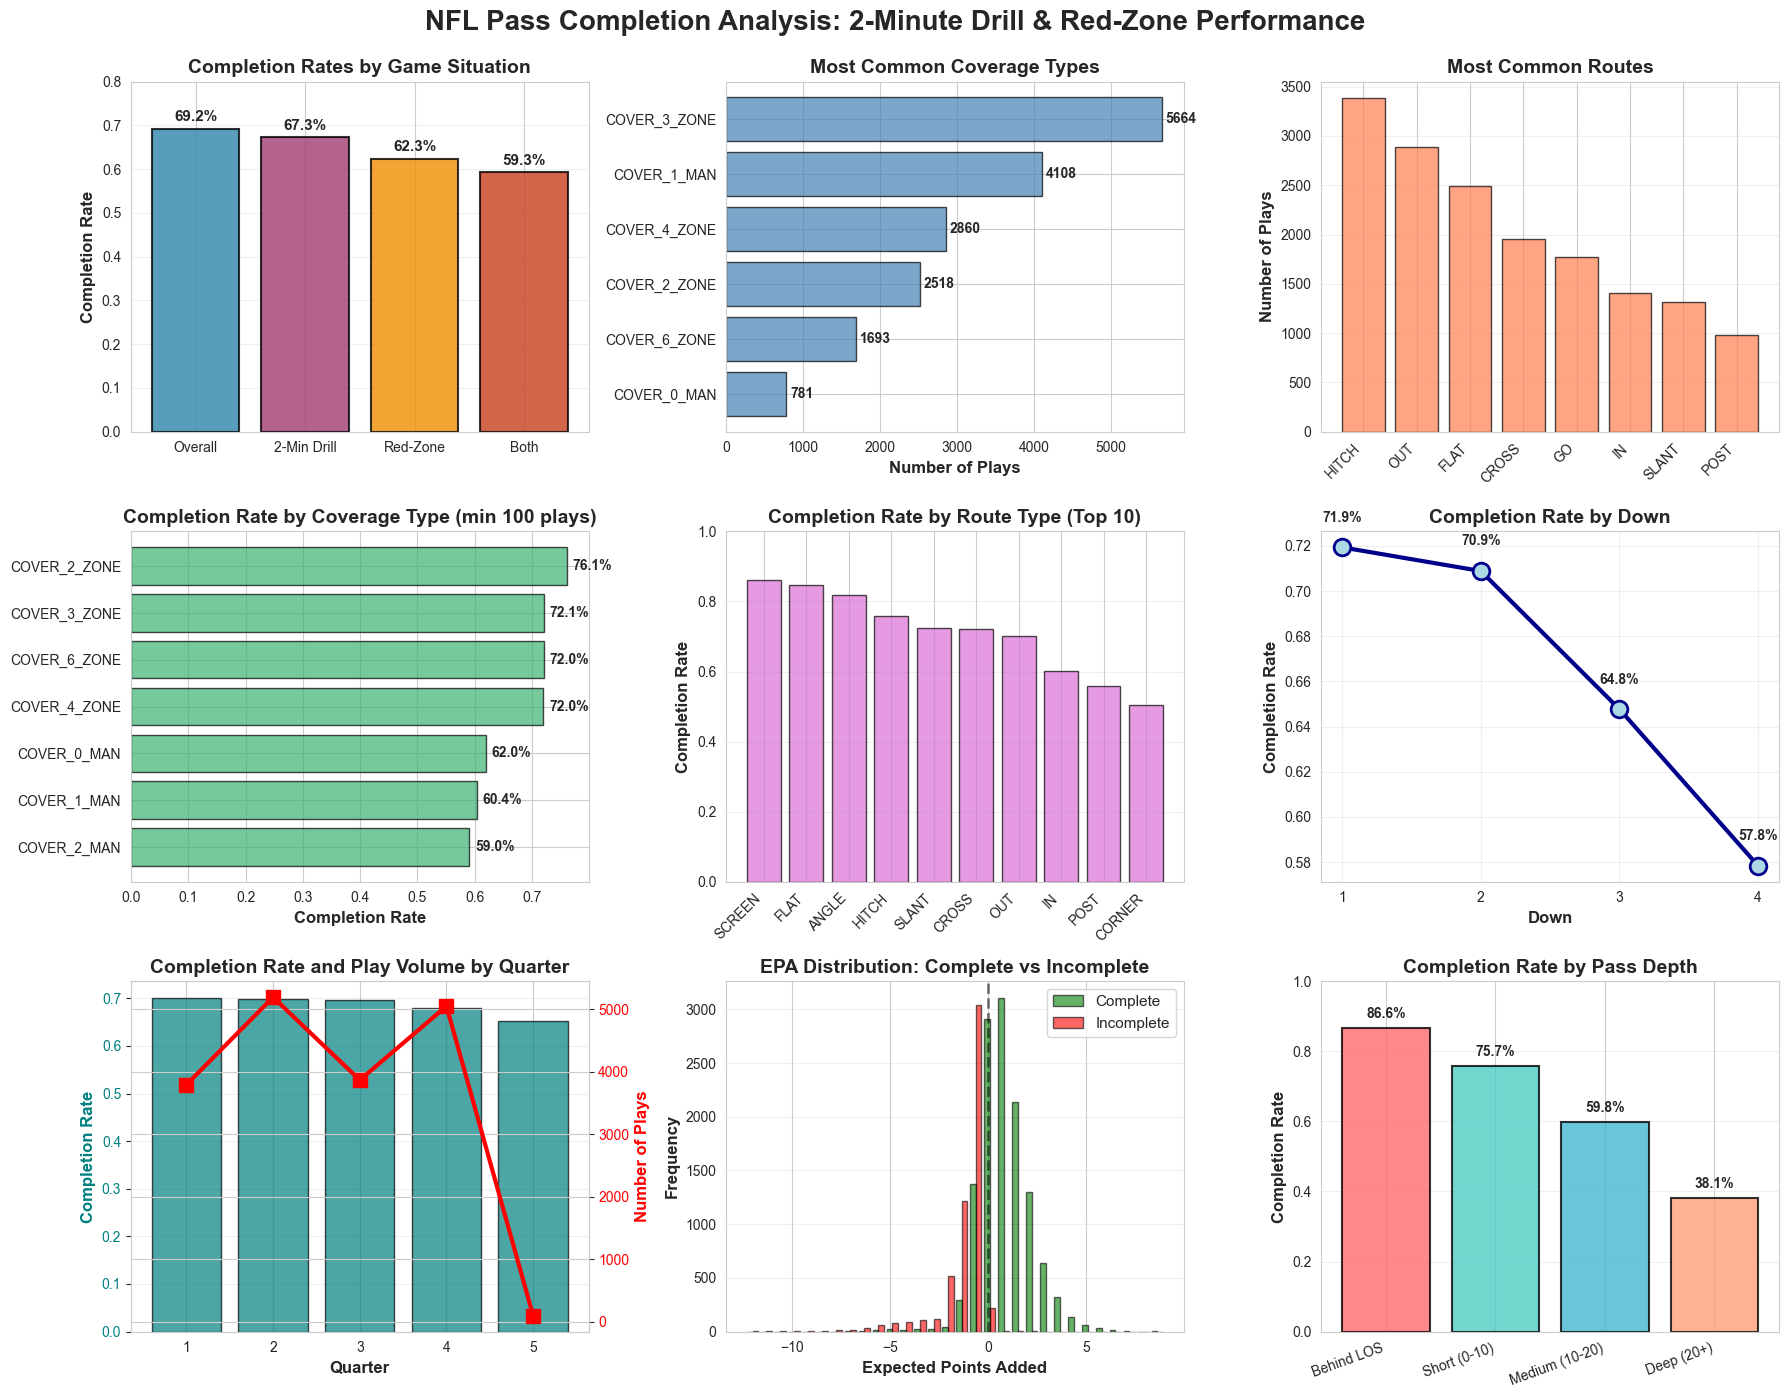

In [79]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('NFL Pass Completion Analysis: 2-Minute Drill & Red-Zone Performance', 
             fontsize=20, fontweight='bold', y=0.995)

# 1. Completion Rates by Situation
ax1 = axes[0, 0]
situations = ['Overall', '2-Min Drill', 'Red-Zone', 'Both']
completion_rates = [
    supp_data['is_completion'].mean(),
    supp_data[supp_data['is_two_minute_drill']]['is_completion'].mean(),
    supp_data[supp_data['is_redzone']]['is_completion'].mean(),
    supp_data[(supp_data['is_two_minute_drill']) & (supp_data['is_redzone'])]['is_completion'].mean()
]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax1.bar(situations, completion_rates, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax1.set_title('Completion Rates by Game Situation', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 0.8)
for i, (bar, rate) in enumerate(zip(bars, completion_rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{rate:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Coverage Type Distribution
ax2 = axes[0, 1]
coverage_counts = supp_data['team_coverage_type'].value_counts().head(6)
ax2.barh(coverage_counts.index, coverage_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Plays', fontsize=12, fontweight='bold')
ax2.set_title('Most Common Coverage Types', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(coverage_counts.values):
    ax2.text(v + 50, i, str(v), va='center', fontsize=10, fontweight='bold')

# 3. Route Distribution
ax3 = axes[0, 2]
route_counts = supp_data['route_of_targeted_receiver'].value_counts().head(8)
ax3.bar(range(len(route_counts)), route_counts.values, color='coral', alpha=0.7, edgecolor='black')
ax3.set_xticks(range(len(route_counts)))
ax3.set_xticklabels(route_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Number of Plays', fontsize=12, fontweight='bold')
ax3.set_title('Most Common Routes', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Completion Rate by Coverage Type
ax4 = axes[1, 0]
coverage_completion = supp_data.groupby('team_coverage_type')['is_completion'].agg(['mean', 'count'])
coverage_completion = coverage_completion[coverage_completion['count'] >= 100].sort_values('mean', ascending=False)
ax4.barh(coverage_completion.index, coverage_completion['mean'], color='mediumseagreen', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Completion Rate', fontsize=12, fontweight='bold')
ax4.set_title('Completion Rate by Coverage Type (min 100 plays)', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(coverage_completion['mean']):
    ax4.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10, fontweight='bold')

# 5. Completion Rate by Route
ax5 = axes[1, 1]
route_completion = supp_data.groupby('route_of_targeted_receiver')['is_completion'].agg(['mean', 'count'])
route_completion = route_completion[route_completion['count'] >= 100].sort_values('mean', ascending=False).head(10)
ax5.bar(range(len(route_completion)), route_completion['mean'], color='orchid', alpha=0.7, edgecolor='black')
ax5.set_xticks(range(len(route_completion)))
ax5.set_xticklabels(route_completion.index, rotation=45, ha='right')
ax5.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax5.set_title('Completion Rate by Route Type (Top 10)', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)

# 6. Down and Distance Analysis
ax6 = axes[1, 2]
down_completion = supp_data.groupby('down')['is_completion'].mean()
ax6.plot(down_completion.index, down_completion.values, marker='o', linewidth=3, 
         markersize=12, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
ax6.set_xlabel('Down', fontsize=12, fontweight='bold')
ax6.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax6.set_title('Completion Rate by Down', fontsize=14, fontweight='bold')
ax6.set_xticks([1, 2, 3, 4])
ax6.grid(True, alpha=0.3)
for x, y in zip(down_completion.index, down_completion.values):
    ax6.text(x, y + 0.01, f'{y:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 7. Quarter Analysis
ax7 = axes[2, 0]
quarter_data = supp_data.groupby('quarter').agg({
    'is_completion': 'mean',
    'play_id': 'count'
})
ax7_twin = ax7.twinx()
bars = ax7.bar(quarter_data.index, quarter_data['is_completion'], color='teal', alpha=0.7, 
               edgecolor='black', label='Completion Rate')
line = ax7_twin.plot(quarter_data.index, quarter_data['play_id'], color='red', marker='s', 
                     linewidth=3, markersize=10, label='Number of Plays')
ax7.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax7.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='teal')
ax7_twin.set_ylabel('Number of Plays', fontsize=12, fontweight='bold', color='red')
ax7.set_title('Completion Rate and Play Volume by Quarter', fontsize=14, fontweight='bold')
ax7.tick_params(axis='y', labelcolor='teal')
ax7_twin.tick_params(axis='y', labelcolor='red')
ax7.grid(axis='y', alpha=0.3)

# 8. Expected Points Added Distribution
ax8 = axes[2, 1]
epa_complete = supp_data[supp_data['is_completion'] == 1]['expected_points_added'].dropna()
epa_incomplete = supp_data[supp_data['is_completion'] == 0]['expected_points_added'].dropna()
ax8.hist([epa_complete, epa_incomplete], bins=30, label=['Complete', 'Incomplete'], 
         color=['green', 'red'], alpha=0.6, edgecolor='black')
ax8.set_xlabel('Expected Points Added', fontsize=12, fontweight='bold')
ax8.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax8.set_title('EPA Distribution: Complete vs Incomplete', fontsize=14, fontweight='bold')
ax8.legend(fontsize=11)
ax8.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax8.grid(axis='y', alpha=0.3)

# 9. Pass Length Analysis
ax9 = axes[2, 2]
pass_length_bins = pd.cut(supp_data['pass_length'], bins=[-50, 0, 10, 20, 100], 
                          labels=['Behind LOS', 'Short (0-10)', 'Medium (10-20)', 'Deep (20+)'])
length_completion = supp_data.groupby(pass_length_bins)['is_completion'].mean()
ax9.bar(range(len(length_completion)), length_completion.values, 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax9.set_xticks(range(len(length_completion)))
ax9.set_xticklabels(length_completion.index, rotation=20, ha='right')
ax9.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax9.set_title('Completion Rate by Pass Depth', fontsize=14, fontweight='bold')
ax9.set_ylim(0, 1)
for i, v in enumerate(length_completion.values):
    ax9.text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax9.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(Path("../visualizations") / 'nfl_completion_analysis_overview.png', dpi=300, bbox_inches='tight')
print("Comprehensive analysis visualization saved!")
plt.show()

# Modeling Two-Minute Drill:

### Data Formation:

In [80]:
# ============================================================================
# STEP 1: Data Formation
# ============================================================================
# Define the base path
BASE_PATH = Path('C:/Users/jrzem/Downloads/NFL-Big-Data-Bowl-2026-Analytics-Challenge/data/raw')

# Load supplementary data with two-minute drill flag
print("Loading supplementary data...")
supp_data = pd.read_csv('C:\\Users\\jrzem\\Downloads\\NFL-Big-Data-Bowl-2026-Analytics-Challenge\\data\\processed\\supplementary_enhanced.csv')
print(f"Supplementary data loaded: {supp_data.shape}")
print(f"Two-minute drill plays: {supp_data['is_two_minute_drill'].sum()}")

# Filter supplementary data to only two-minute drill plays
supp_data_2min = supp_data[supp_data['is_two_minute_drill'] == True].copy()
print(f"Filtered to two-minute drill plays only: {supp_data_2min.shape}")

# Load all weeks using pathlib for cross-platform compatibility
all_input_files = sorted(BASE_PATH.glob('input_2023_w*.csv'))

# Convert Path objects to strings for pandas
all_input_files = [str(f) for f in all_input_files]

print(f"\nFound {len(all_input_files)} input files")

if len(all_input_files) > 0:
    print("\nInput files found:")
    for f in all_input_files[:5]:  # Show first 5
        print(f"  - {Path(f).name}")
    if len(all_input_files) > 5:
        print(f"  ... and {len(all_input_files) - 5} more")

# Define feature extraction function
def extract_comprehensive_features(df, week_num, supp_df):
    """Extract comprehensive features from tracking data"""
    features_list = []
    
    # Get unique plays
    plays = df.groupby(['game_id', 'play_id'])
    
    for (game_id, play_id), play_data in plays:
        # Check if this play exists in the filtered supplementary data (two-minute drill only)
        supp_play = supp_df[(supp_df['game_id'] == game_id) & (supp_df['play_id'] == play_id)]
        if len(supp_play) == 0:
            continue  # Skip plays that are not two-minute drill
        
        is_two_min = supp_play.iloc[0]['is_two_minute_drill']
        
        # Get last frame (before pass)
        last_frame = play_data['frame_id'].max()
        last_frame_data = play_data[play_data['frame_id'] == last_frame]
        
        # Get targeted receiver
        targeted = last_frame_data[last_frame_data['player_role'] == 'Targeted Receiver']
        if len(targeted) == 0:
            continue
            
        targeted = targeted.iloc[0]
        
        # Get passer
        passer = last_frame_data[last_frame_data['player_role'] == 'Passer']
        if len(passer) == 0:
            continue
        passer = passer.iloc[0]
        
        # Get defenders
        defenders = last_frame_data[last_frame_data['player_side'] == 'Defense']
        
        # Calculate features
        features = {
            'game_id': game_id,
            'play_id': play_id,
            'week': week_num,
            'is_two_minute_drill': is_two_min,
            
            # Receiver features
            'receiver_x': targeted['x'],
            'receiver_y': targeted['y'],
            'receiver_speed': targeted['s'],
            'receiver_acceleration': targeted['a'],
            'receiver_direction': targeted['dir'],
            'receiver_orientation': targeted['o'],
            
            # Passer features
            'passer_x': passer['x'],
            'passer_y': passer['y'],
            'passer_speed': passer['s'],
            
            # Ball landing
            'ball_land_x': targeted['ball_land_x'],
            'ball_land_y': targeted['ball_land_y'],
            
            # Distance calculations
            'dist_to_ball_land': np.sqrt((targeted['x'] - targeted['ball_land_x'])**2 + 
                                         (targeted['y'] - targeted['ball_land_y'])**2),
            'dist_from_passer': np.sqrt((targeted['x'] - passer['x'])**2 + 
                                       (targeted['y'] - passer['y'])**2),
            
            # Defender proximity
            'num_defenders': len(defenders),
            'closest_defender_dist': defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2), 
                axis=1
            ).min() if len(defenders) > 0 else np.nan,
            
            'avg_defender_dist': defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2), 
                axis=1
            ).mean() if len(defenders) > 0 else np.nan,
            
            # Defenders within radius
            'defenders_within_5yds': sum(defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2) <= 5, 
                axis=1
            )) if len(defenders) > 0 else 0,
            
            'defenders_within_10yds': sum(defenders.apply(
                lambda d: np.sqrt((targeted['x'] - d['x'])**2 + (targeted['y'] - d['y'])**2) <= 10, 
                axis=1
            )) if len(defenders) > 0 else 0,
        }
        
        # Trajectory analysis - look at last 5 frames
        receiver_id = targeted['nfl_id']
        receiver_trajectory = play_data[
            (play_data['nfl_id'] == receiver_id) & 
            (play_data['frame_id'] >= max(1, last_frame - 4))
        ].sort_values('frame_id')
        
        if len(receiver_trajectory) >= 2:
            # Speed change
            features['speed_change'] = receiver_trajectory['s'].iloc[-1] - receiver_trajectory['s'].iloc[0]
            features['max_speed'] = receiver_trajectory['s'].max()
            features['avg_speed'] = receiver_trajectory['s'].mean()
            
            # Direction change
            features['direction_change'] = abs(receiver_trajectory['dir'].iloc[-1] - receiver_trajectory['dir'].iloc[0])
            
            # Distance covered
            positions = receiver_trajectory[['x', 'y']].values
            features['distance_covered'] = sum(
                np.sqrt(np.sum((positions[i] - positions[i-1])**2)) 
                for i in range(1, len(positions))
            )
        else:
            features['speed_change'] = 0
            features['max_speed'] = targeted['s']
            features['avg_speed'] = targeted['s']
            features['direction_change'] = 0
            features['distance_covered'] = 0
        
        features_list.append(features)
    
    return pd.DataFrame(features_list)

# Process all weeks
if len(all_input_files) > 0:
    print("\n" + "="*60)
    print("PROCESSING ALL INPUT FILES (TWO-MINUTE DRILL ONLY)")
    print("="*60)
    all_features = []
    
    for input_file in all_input_files:
        filename = Path(input_file).name
        # Extract week number from filename (e.g., input_2023_w01.csv -> 1)
        week_num = int(filename.split('_w')[1].split('.')[0])
        
        try:
            print(f"\nProcessing {filename} (Week {week_num})...")
            df = pd.read_csv(input_file)
            week_features = extract_comprehensive_features(df, week_num, supp_data_2min)
            all_features.append(week_features)
            print(f"  ✓ Extracted {len(week_features)} two-minute drill plays from week {week_num}")
        except FileNotFoundError:
            print(f"  ✗ {filename} not found, skipping...")
        except Exception as e:
            print(f"  ✗ Error processing {filename}: {e}")
    
    # Combine all features
    if len(all_features) > 0:
        tracking_features = pd.concat(all_features, ignore_index=True)
        print("\n" + "="*60)
        print("FEATURE EXTRACTION COMPLETE")
        print("="*60)
        print(f"Total tracking features extracted: {tracking_features.shape}")
        print(f"Columns: {len(tracking_features.columns)}")
        print(f"\nColumn names:")
        for i, col in enumerate(tracking_features.columns.tolist(), 1):
            print(f"  {i:2d}. {col}")
        
        # Summary of two-minute drill plays
        print("\n" + "="*60)
        print("TWO-MINUTE DRILL SUMMARY")
        print("="*60)
        print(f"Two-minute drill plays in tracking features: {tracking_features['is_two_minute_drill'].sum()}")
        print(f"Total plays: {len(tracking_features)}")
        print(f"Percentage: {tracking_features['is_two_minute_drill'].mean()*100:.1f}%")
        print("(Should be 100% since we filtered for two-minute drill only)")
        
        # Merge tracking features with supplementary data (two-minute drill only)
        print("\n" + "="*60)
        print("MERGING WITH SUPPLEMENTARY DATA (TWO-MINUTE DRILL ONLY)")
        print("="*60)
        merged_data = tracking_features.merge(
            supp_data_2min, 
            on=['game_id', 'play_id'], 
            how='inner',
            suffixes=('_tracking', '_supp')  # Use clearer suffixes
        )
        
        print(f"Merged data shape: {merged_data.shape}")
        
        # Clean up duplicate columns - keep tracking version for week and is_two_minute_drill
        if 'week_tracking' in merged_data.columns and 'week_supp' in merged_data.columns:
            merged_data['week'] = merged_data['week_tracking']
            merged_data.drop(['week_tracking', 'week_supp'], axis=1, inplace=True)
        
        if 'is_two_minute_drill_tracking' in merged_data.columns and 'is_two_minute_drill_supp' in merged_data.columns:
            merged_data['is_two_minute_drill'] = merged_data['is_two_minute_drill_tracking']
            merged_data.drop(['is_two_minute_drill_tracking', 'is_two_minute_drill_supp'], axis=1, inplace=True)
        
        # Verify all plays are two-minute drill
        print(f"\nVerification: All plays are two-minute drill? {merged_data['is_two_minute_drill'].all()}")
        
        # Check for missing values
        missing_vals = merged_data.isnull().sum()
        missing_vals = missing_vals[missing_vals > 0]
        if len(missing_vals) > 0:
            print(f"\nMissing values:")
            for col, count in missing_vals.items():
                print(f"  - {col}: {count} ({count/len(merged_data)*100:.1f}%)")
        else:
            print("\n✓ No missing values!")
        
        # Save merged data
        merged_data.to_csv('Two-Minute Drill/comprehensive_analysis_data_2min_drill.csv', index=False)
        print("\n✓ Saved comprehensive_analysis_data_2min_drill.csv")
        
        # Display summary statistics
        print("\n" + "="*60)
        print("DATA SUMMARY (TWO-MINUTE DRILL ONLY)")
        print("="*60)
        print(f"Total plays: {len(merged_data)}")
        print(f"Completion rate: {merged_data['is_completion'].mean():.3f}")
        print(f"Weeks covered: {sorted(merged_data['week'].unique())}")
        print(f"\nKey features available:")
        print(f"  - Tracking features: {len(tracking_features.columns)}")
        print(f"  - Supplementary features: {len(supp_data_2min.columns)}")
        print(f"  - Total merged features: {len(merged_data.columns)}")
        
        # Additional two-minute drill statistics
        print(f"\nTwo-Minute Drill Statistics:")
        print(f"  - Total two-minute drill plays: {len(merged_data)}")
        print(f"  - Completion rate: {merged_data['is_completion'].mean():.3f}")
        print(f"  - Average EPA: {merged_data['expected_points_added'].mean():.3f}")
        print(f"  - Average pass length: {merged_data['pass_length'].mean():.2f} yards")
        
        # Quarter breakdown
        print(f"\nQuarter Breakdown:")
        quarter_stats = merged_data.groupby('quarter').agg({
            'play_id': 'count',
            'is_completion': 'mean',
            'expected_points_added': 'mean'
        }).round(3)
        quarter_stats.columns = ['Plays', 'Completion Rate', 'Avg EPA']
        print(quarter_stats)
        
    else:
        print("\n❌ No features extracted from any files.")
else:
    print("\n❌ No input files found. Please check the BASE_PATH.")

Loading supplementary data...
Supplementary data loaded: (18009, 46)
Two-minute drill plays: 2762
Filtered to two-minute drill plays only: (2762, 46)

Found 18 input files

Input files found:
  - input_2023_w01.csv
  - input_2023_w02.csv
  - input_2023_w03.csv
  - input_2023_w04.csv
  - input_2023_w05.csv
  ... and 13 more

PROCESSING ALL INPUT FILES (TWO-MINUTE DRILL ONLY)

Processing input_2023_w01.csv (Week 1)...
  ✓ Extracted 129 two-minute drill plays from week 1

Processing input_2023_w02.csv (Week 2)...
  ✓ Extracted 133 two-minute drill plays from week 2

Processing input_2023_w03.csv (Week 3)...
  ✓ Extracted 136 two-minute drill plays from week 3

Processing input_2023_w04.csv (Week 4)...
  ✓ Extracted 112 two-minute drill plays from week 4

Processing input_2023_w05.csv (Week 5)...
  ✓ Extracted 113 two-minute drill plays from week 5

Processing input_2023_w06.csv (Week 6)...
  ✓ Extracted 128 two-minute drill plays from week 6

Processing input_2023_w07.csv (Week 7)...
  ✓ 

### Predictive Modeling:

In [81]:
import numpy as np
import pandas as pd

from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    average_precision_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor  # for quantiles
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 42

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_get_cols(df, cols, fill_value=0):
    """Return df[cols] but if some cols are missing, create them with fill_value."""
    df = df.copy()
    missing = [c for c in cols if c not in df.columns]
    for c in missing:
        df[c] = fill_value
    return df[cols]

@dataclass
class ClfMetrics:
    brier: float
    logloss: float
    auc: float
    ap: float

@dataclass
class RegMetrics:
    mae: float
    rmse: float
    r2: float

In [82]:
# =========================
# CONFIG
# =========================
WEEK_COL = "week"  # must exist in merged_data
TARGET_CLF = "is_completion"
TARGET_YARDS = "yards_gained"

# If you truly want pre-snap, consider also removing ball landing derived features.
# Leaving False to match your request (only remove pass_length), but see note below.
PRE_SNAP_MODE = False

# Base numeric features (removed pass_length)
numeric_features = [
    'receiver_speed', 'receiver_acceleration', 'receiver_direction',
    'passer_speed',
    'dist_from_passer',
    'closest_defender_dist', 'avg_defender_dist',
    'defenders_within_5yds', 'defenders_within_10yds',
    'speed_change', 'max_speed', 'avg_speed', 'direction_change',
    'distance_covered', 'down', 'yards_to_go', 'quarter',
    'defenders_in_the_box', 'dropback_distance',
    'yardline_number', 'yards_to_endzone',
    'is_two_minute_drill', 'is_redzone', 'play_action'
]

if PRE_SNAP_MODE:
    # Strongly recommended if you want coaches to use it pre-snap.
    # dist_to_ball_land is almost certainly leaking future info.
    numeric_features = [c for c in numeric_features if c not in ["dist_to_ball_land"]]

cat_cols = {
    "coverage_type": "team_coverage_type",
    "man_zone": "team_coverage_man_zone",
    "route": "route_of_targeted_receiver",
    "formation": "offense_formation"
}

def bucket_coverage_shell(coverage_type: str) -> str:
    """Map detailed coverage labels into a shell proxy. Adjust mapping to match your data."""
    s = str(coverage_type).upper().replace(" ", "_")
    if "UNKNOWN" in s or s == "NAN":
        return "unknown"
    # Common heuristics:
    if "COVER_0" in s or "ZERO" in s:
        return "zero"
    if "COVER_1" in s or "COVER_3" in s or "COVER_4" in s:
        return "single_high"
    if "COVER_2" in s or "COVER_6" in s or "TWO" in s:
        return "two_high"
    if "PREVENT" in s:
        return "prevent"
    return "other"

def bucket_route(route: str) -> str:
    s = str(route).upper()
    if s in ["UNKNOWN", "NAN"]:
        return "unknown"
    # Buckets you asked for (edit as needed)
    if s in ["SLANT", "IN", "DIG", "POST"]:     # in-breaking (post is a hybrid; okay for simple)
        return "in_breaking"
    if s in ["OUT", "CORNER", "COMEBACK"]:      # if comeback exists
        return "out_breaking"
    if s in ["GO", "FADE", "SEAM", "POST"]:     # vertical bucket
        return "vertical"
    if s in ["FLAT", "SCREEN", "BUBBLE"]:
        return "flat_screen"
    if s in ["CROSS", "DRAG", "OVER"]:
        return "crossers"
    return "other"

def bucket_formation(form: str) -> str:
    s = str(form).upper().replace(" ", "_")
    if s in ["UNKNOWN", "NAN"]:
        return "unknown"
    if "SHOTGUN" in s:
        return "shotgun"
    if "PISTOL" in s:
        return "pistol"
    if "WILDCAT" in s:
        return "wildcat"
    if "JUMBO" in s:
        return "jumbo"
    # crude under-center proxy
    if any(k in s for k in ["I_FORM", "SINGLEBACK", "ACE", "UNDER_CENTER"]):
        return "under_center"
    return "other"

def build_features(model_data: pd.DataFrame):
    """Return (X_full_onehot, X_bucketed, feature_names_full, feature_names_bucketed)."""
    df = model_data.copy()

    # ensure categorical columns exist
    for k, col in cat_cols.items():
        if col not in df.columns:
            df[col] = "Unknown"

    # numeric matrix (robust to missing cols)
    X_num = safe_get_cols(df, numeric_features, fill_value=0).fillna(0)

    # ---------- Full one-hot ----------
    cov_oh = pd.get_dummies(df[cat_cols["coverage_type"]].fillna("Unknown"), prefix="coverage", drop_first=True)
    route_oh = pd.get_dummies(df[cat_cols["route"]].fillna("Unknown"), prefix="route", drop_first=True)
    form_oh = pd.get_dummies(df[cat_cols["formation"]].fillna("Unknown"), prefix="formation", drop_first=True)

    X_full = pd.concat([X_num, cov_oh, route_oh, form_oh], axis=1)
    full_cols = X_full.columns.tolist()

    # ---------- Bucketed (coach-friendly) ----------
    df["coverage_shell"] = df[cat_cols["coverage_type"]].fillna("Unknown").map(bucket_coverage_shell)
    df["route_bucket"] = df[cat_cols["route"]].fillna("Unknown").map(bucket_route)
    df["formation_bucket"] = df[cat_cols["formation"]].fillna("Unknown").map(bucket_formation)

    # Use man/zone directly + shell proxy + route bucket + formation bucket
    man_zone_oh = pd.get_dummies(df[cat_cols["man_zone"]].fillna("Unknown"), prefix="manzone", drop_first=True)
    shell_oh = pd.get_dummies(df["coverage_shell"].fillna("unknown"), prefix="shell", drop_first=True)
    route_b_oh = pd.get_dummies(df["route_bucket"].fillna("unknown"), prefix="routeB", drop_first=True)
    form_b_oh = pd.get_dummies(df["formation_bucket"].fillna("unknown"), prefix="formB", drop_first=True)

    X_bucketed = pd.concat([X_num, man_zone_oh, shell_oh, route_b_oh, form_b_oh], axis=1)
    bucket_cols = X_bucketed.columns.tolist()

    return X_full, X_bucketed, full_cols, bucket_cols

# Build model_data and features
model_data = merged_data.copy()

# Minimal safety checks
assert WEEK_COL in model_data.columns, f"Need `{WEEK_COL}` column in merged_data for week-based split."
assert TARGET_CLF in model_data.columns, f"Need `{TARGET_CLF}` target column."
assert TARGET_YARDS in model_data.columns, f"Need `{TARGET_YARDS}` target column."

X_full_onehot, X_bucketed, full_cols, bucket_cols = build_features(model_data)

print(f"Full one-hot features: {X_full_onehot.shape[1]}")
print(f"Bucketed features:     {X_bucketed.shape[1]}")

Full one-hot features: 49
Bucketed features:     40


In [83]:
# Sort unique weeks
weeks = sorted(pd.Series(model_data[WEEK_COL].dropna().unique()).astype(int).tolist())

if len(weeks) < 3:
    raise ValueError(f"Need >=3 unique weeks for train/val/test by week. Found: {weeks}")

train_weeks = weeks[:-2]   # 1..k-1
val_week = weeks[-2]       # k
test_week = weeks[-1]      # k+1

train_mask = model_data[WEEK_COL].astype(int).isin(train_weeks)
val_mask   = model_data[WEEK_COL].astype(int).eq(val_week)
test_mask  = model_data[WEEK_COL].astype(int).eq(test_week)

print(f"Weeks: {weeks}")
print(f"Train weeks: {train_weeks}")
print(f"Val week:    {val_week}")
print(f"Test week:   {test_week}")
print(f"Rows train/val/test: {train_mask.sum()}/{val_mask.sum()}/{test_mask.sum()}")

Weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Train weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Val week:    17
Test week:   18
Rows train/val/test: 1888/113/133


LR (scaled)  | Brier=0.1929  LogLoss=0.5753  AUC=0.6930  AP=0.8214
HistGB       | Brier=0.1860  LogLoss=0.5764  AUC=0.7278  AP=0.8469
RF           | Brier=0.1825  LogLoss=0.5477  AUC=0.7245  AP=0.8373

Best classifier by (Brier, LogLoss, AUC): RF

TEST metrics (RF): Brier=0.1702  LogLoss=0.5131  AUC=0.7902  AP=0.8827

Traffic Light Counts (Test Week):
Green     55
Yellow    46
Red       32
Name: count, dtype: int64


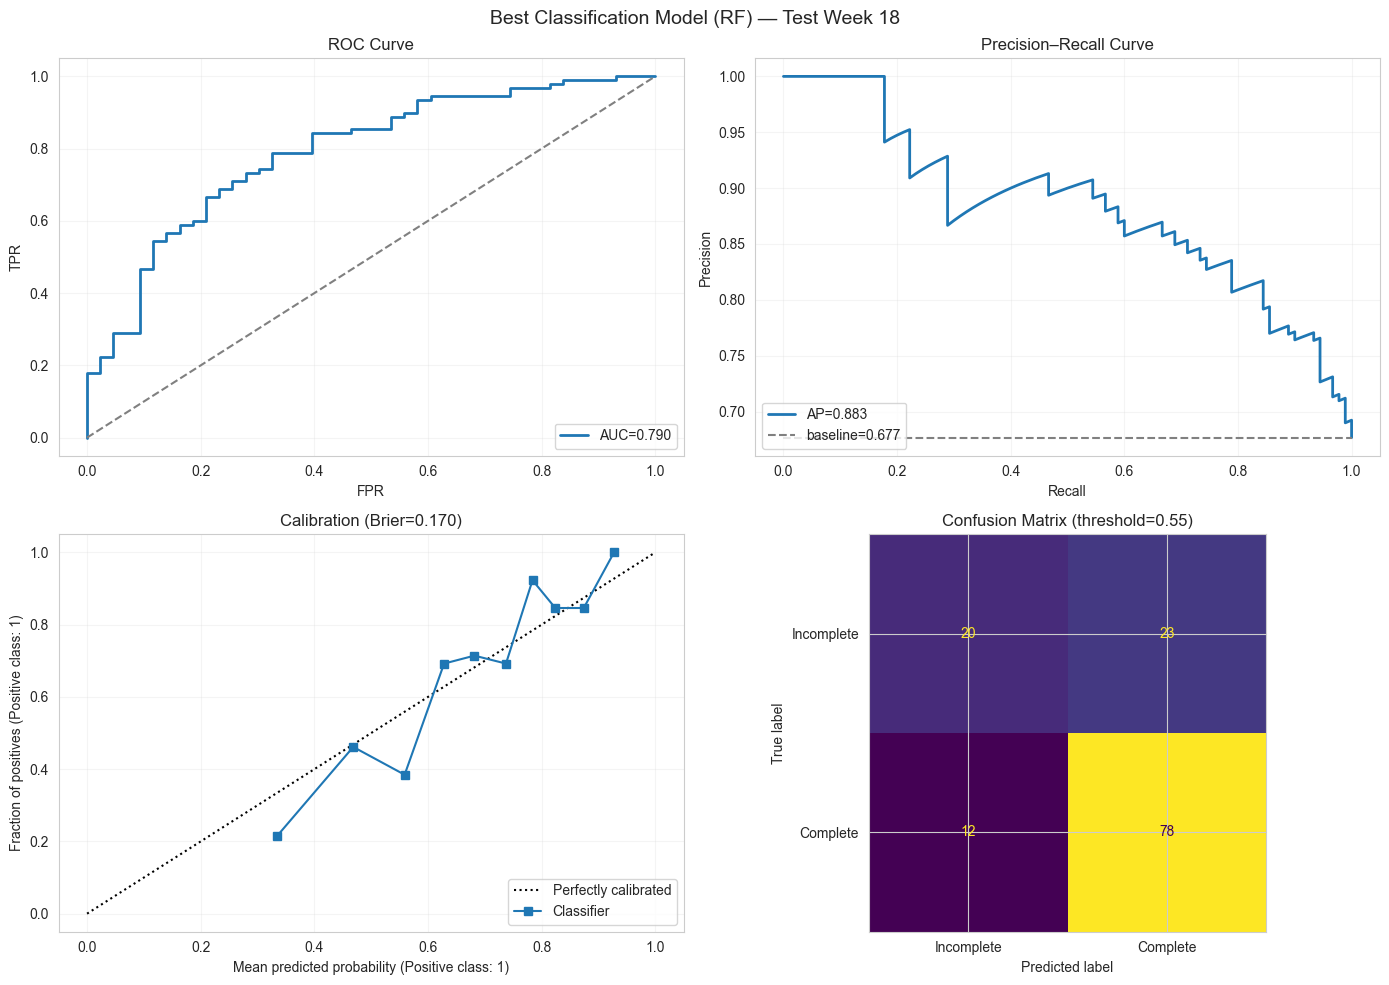

         n  completion_rate
band                       
Red     32         0.375000
Yellow  46         0.630435
Green   55         0.890909
Calibrated TEST: ClfMetrics(brier=0.17148734178589672, logloss=0.5138887349975945, auc=0.7799741602067184, ap=0.8558814517866702)


In [84]:
from copy import deepcopy

import numpy as np
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, average_precision_score

def stable_log_loss(y_true, proba_pos, clip=1e-15):
    """
    Compatible across sklearn versions (no eps kwarg).
    - Clips proba for numeric stability
    - Forces labels=[0,1] so log_loss won't break if a split is missing a class
    """
    p = np.asarray(proba_pos, dtype=float)
    p = np.clip(p, clip, 1 - clip)
    return float(log_loss(y_true, p, labels=[0, 1]))

def safe_auc(y_true, proba_pos):
    """AUC is undefined if only one class exists in y_true (can happen with week splits)."""
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return float(roc_auc_score(y_true, proba_pos))

def safe_ap(y_true, proba_pos):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return float(average_precision_score(y_true, proba_pos))

def eval_classifier(model, X_tr, y_tr, X_ev, y_ev):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_ev)[:, 1]
    return ClfMetrics(
        brier=float(brier_score_loss(y_ev, proba)),
        logloss=stable_log_loss(y_ev, proba),
        auc=safe_auc(y_ev, proba),
        ap=safe_ap(y_ev, proba),
    )

def pick_best_classifier(results: dict):
    """
    results: dict[name] -> (metrics, fitted_model_like)
    Choose by: Brier (asc), logloss (asc), AUC (desc)
    """
    ranked = sorted(
        results.items(),
        key=lambda kv: (kv[1]["metrics"].brier, kv[1]["metrics"].logloss, -kv[1]["metrics"].auc)
    )
    return ranked[0][0], ranked

# Data splits
y = model_data[TARGET_CLF].astype(int)

X_tr_full = X_full_onehot.loc[train_mask]
X_va_full = X_full_onehot.loc[val_mask]
X_te_full = X_full_onehot.loc[test_mask]

y_tr = y.loc[train_mask]
y_va = y.loc[val_mask]
y_te = y.loc[test_mask]

# Candidate models (better learning than original GBClassifier, still manageable)
clf_candidates = {
    "LR (scaled)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),  # sparse-safe
        ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=None))
    ]),
    "HistGB": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=4,
        learning_rate=0.06,
        max_iter=400
    ),
    "RF": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

clf_results = {}
for name, model in clf_candidates.items():
    m = deepcopy(model)
    metrics = eval_classifier(m, X_tr_full, y_tr, X_va_full, y_va)
    clf_results[name] = {"model": m, "metrics": metrics}
    print(f"{name:12s} | Brier={metrics.brier:.4f}  LogLoss={metrics.logloss:.4f}  AUC={metrics.auc:.4f}  AP={metrics.ap:.4f}")

best_clf_name, ranked = pick_best_classifier(clf_results)
best_clf_model = clf_results[best_clf_name]["model"]
print("\nBest classifier by (Brier, LogLoss, AUC):", best_clf_name)

# Fit best on train+val, evaluate on test
X_trva = pd.concat([X_tr_full, X_va_full], axis=0)
y_trva = pd.concat([y_tr, y_va], axis=0)
best_clf_model.fit(X_trva, y_trva)
proba_te = best_clf_model.predict_proba(X_te_full)[:, 1]

test_metrics = ClfMetrics(
    brier=float(brier_score_loss(y_te, proba_te)),
    logloss=stable_log_loss(y_te, proba_te),
    auc=safe_auc(y_te, proba_te),
    ap=safe_ap(y_te, proba_te),
)
print(f"\nTEST metrics ({best_clf_name}): Brier={test_metrics.brier:.4f}  LogLoss={test_metrics.logloss:.4f}  AUC={test_metrics.auc:.4f}  AP={test_metrics.ap:.4f}")

# Traffic light labels
def prob_to_color(p):
    if p >= 0.75:
        return "Green"
    if p >= 0.55:
        return "Yellow"
    return "Red"

traffic = pd.Series(proba_te).apply(prob_to_color).value_counts()
print("\nTraffic Light Counts (Test Week):")
print(traffic)

# Plots for BEST model (no hard-coding)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Best Classification Model ({best_clf_name}) — Test Week {test_week}", fontsize=14)

# ROC
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_te, proba_te)
ax.plot(fpr, tpr, linewidth=2, label=f"AUC={test_metrics.auc:.3f}")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curve")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.grid(alpha=0.2)
ax.legend(loc="lower right")

# PR
ax = axes[0, 1]
prec, rec, _ = precision_recall_curve(y_te, proba_te)
baseline = float(y_te.mean())
ax.plot(rec, prec, linewidth=2, label=f"AP={test_metrics.ap:.3f}")
ax.hlines(baseline, 0, 1, colors="gray", linestyles="--", label=f"baseline={baseline:.3f}")
ax.set_title("Precision–Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.2)
ax.legend(loc="lower left")

# Calibration
ax = axes[1, 0]
CalibrationDisplay.from_predictions(y_te, proba_te, n_bins=10, strategy="quantile", ax=ax)
ax.set_title(f"Calibration (Brier={test_metrics.brier:.3f})")
ax.grid(alpha=0.2)

# Confusion matrix at 0.55 (coach “Yellow+” as positive)
ax = axes[1, 1]
yhat_055 = (proba_te >= 0.55).astype(int)
cm = confusion_matrix(y_te, yhat_055)
ConfusionMatrixDisplay(cm, display_labels=["Incomplete", "Complete"]).plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Confusion Matrix (threshold=0.55)")

plt.tight_layout()
plt.show()

df_band = pd.DataFrame({"p": proba_te, "y": y_te.values})
df_band["band"] = pd.cut(
    df_band["p"],
    bins=[-np.inf, 0.55, 0.75, np.inf],
    labels=["Red", "Yellow", "Green"]
)

summary = df_band.groupby("band").agg(
    n=("y", "size"),
    completion_rate=("y", "mean"),
)
print(summary)

from sklearn.isotonic import IsotonicRegression

# Fit base model on TRAIN only
base = deepcopy(best_clf_model)
base.fit(X_tr_full, y_tr)

# Calibrate on VAL week
p_val = base.predict_proba(X_va_full)[:, 1]
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(p_val, y_va)

# Apply to TEST week
p_test_uncal = base.predict_proba(X_te_full)[:, 1]
p_test_cal = iso.transform(p_test_uncal)

# Evaluate calibrated
cal_metrics = ClfMetrics(
    brier=float(brier_score_loss(y_te, p_test_cal)),
    logloss=stable_log_loss(y_te, p_test_cal),
    auc=safe_auc(y_te, p_test_cal),
    ap=safe_ap(y_te, p_test_cal),
)
print("Calibrated TEST:", cal_metrics)

In [85]:
# =========================
# Regression dataset (only completed passes)
# =========================
complete_mask = (model_data[TARGET_CLF].astype(int) == 1)

train_c = train_mask & complete_mask
val_c   = val_mask & complete_mask
test_c  = test_mask & complete_mask

X_tr_reg = X_full_onehot.loc[train_c]
X_va_reg = X_full_onehot.loc[val_c]
X_te_reg = X_full_onehot.loc[test_c]

y_tr_reg = model_data.loc[train_c, TARGET_YARDS].fillna(0).astype(float)
y_va_reg = model_data.loc[val_c, TARGET_YARDS].fillna(0).astype(float)
y_te_reg = model_data.loc[test_c, TARGET_YARDS].fillna(0).astype(float)

print(f"Completed passes train/val/test: {len(y_tr_reg)}/{len(y_va_reg)}/{len(y_te_reg)}")
print(f"Test mean yards: {y_te_reg.mean():.2f}, median: {y_te_reg.median():.2f}")

# =========================
# Candidate regressors (mean prediction)
# Pick best by MAE (then RMSE)
# =========================
reg_candidates = {
    "Ridge (scaled)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "HistGB": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        max_depth=4,
        learning_rate=0.06,
        max_iter=400
    ),
    "RF": RandomForestRegressor(
        n_estimators=400,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

reg_results = {}
for name, model in reg_candidates.items():
    m = deepcopy(model)
    m.fit(X_tr_reg, y_tr_reg)
    pred_va = m.predict(X_va_reg)
    metrics = RegMetrics(
        mae=float(mean_absolute_error(y_va_reg, pred_va)),
        rmse=float(rmse(y_va_reg, pred_va)),
        r2=float(r2_score(y_va_reg, pred_va)),
    )
    reg_results[name] = {"model": m, "metrics": metrics}
    print(f"{name:12s} | MAE={metrics.mae:.3f}  RMSE={metrics.rmse:.3f}  R2={metrics.r2:.3f}")

best_reg_name = sorted(reg_results.items(), key=lambda kv: (kv[1]["metrics"].mae, kv[1]["metrics"].rmse))[0][0]
best_reg_model = reg_results[best_reg_name]["model"]
print("\nBest regressor by (MAE, RMSE):", best_reg_name)

# Fit best regressor on train+val (completed only), evaluate on test (completed only)
X_trva_reg = pd.concat([X_tr_reg, X_va_reg], axis=0)
y_trva_reg = pd.concat([y_tr_reg, y_va_reg], axis=0)
best_reg_model.fit(X_trva_reg, y_trva_reg)

pred_te_mean = best_reg_model.predict(X_te_reg)
test_reg_metrics = RegMetrics(
    mae=float(mean_absolute_error(y_te_reg, pred_te_mean)),
    rmse=float(rmse(y_te_reg, pred_te_mean)),
    r2=float(r2_score(y_te_reg, pred_te_mean)),
)
print(f"\nTEST metrics ({best_reg_name}): MAE={test_reg_metrics.mae:.3f}  RMSE={test_reg_metrics.rmse:.3f}  R2={test_reg_metrics.r2:.3f}")

# =========================
# Uncertainty band via quantile regression (10th/90th percentiles)
# Uses GradientBoostingRegressor quantile loss for simplicity/robustness.
# =========================
q_lo, q_hi = 0.10, 0.90

q_model_lo = GradientBoostingRegressor(
    loss="quantile", alpha=q_lo, random_state=RANDOM_STATE,
    n_estimators=300, max_depth=3, learning_rate=0.06
)
q_model_hi = GradientBoostingRegressor(
    loss="quantile", alpha=q_hi, random_state=RANDOM_STATE,
    n_estimators=300, max_depth=3, learning_rate=0.06
)

q_model_lo.fit(X_trva_reg, y_trva_reg)
q_model_hi.fit(X_trva_reg, y_trva_reg)

pred_te_lo = q_model_lo.predict(X_te_reg)
pred_te_hi = q_model_hi.predict(X_te_reg)

# =========================
# Explosive play probability model (yards >= 20) GIVEN completion
# =========================
EXPLOSIVE_YARDS = 20
y_tr_exp = (y_tr_reg >= EXPLOSIVE_YARDS).astype(int)
y_va_exp = (y_va_reg >= EXPLOSIVE_YARDS).astype(int)
y_te_exp = (y_te_reg >= EXPLOSIVE_YARDS).astype(int)

exp_clf_candidates = {
    "LR (scaled)": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "HistGB": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE, max_depth=3, learning_rate=0.06, max_iter=400
    ),
}

exp_results = {}
for name, model in exp_clf_candidates.items():
    m = deepcopy(model)
    metrics = eval_classifier(m, X_tr_reg, y_tr_exp, X_va_reg, y_va_exp)
    exp_results[name] = {"model": m, "metrics": metrics}
    print(f"[Explosive|Complete] {name:10s} | Brier={metrics.brier:.4f} LogLoss={metrics.logloss:.4f} AUC={metrics.auc:.4f} AP={metrics.ap:.4f}")

best_exp_name, _ = pick_best_classifier(exp_results)
best_exp_model = exp_results[best_exp_name]["model"]
print("\nBest explosive classifier:", best_exp_name)

best_exp_model.fit(X_trva_reg, (y_trva_reg >= EXPLOSIVE_YARDS).astype(int))
proba_exp_te = best_exp_model.predict_proba(X_te_reg)[:, 1]

exp_test_metrics = ClfMetrics(
    brier=float(brier_score_loss(y_te_exp, proba_exp_te)),
    logloss=stable_log_loss(y_te_exp, proba_exp_te),
    auc=float(roc_auc_score(y_te_exp, proba_exp_te)),
    ap=float(average_precision_score(y_te_exp, proba_exp_te)),
)
print(f"TEST explosive metrics ({best_exp_name}): Brier={exp_test_metrics.brier:.4f} LogLoss={exp_test_metrics.logloss:.4f} AUC={exp_test_metrics.auc:.4f} AP={exp_test_metrics.ap:.4f}")

Completed passes train/val/test: 1276/78/90
Test mean yards: 10.63, median: 7.50
Ridge (scaled) | MAE=5.115  RMSE=8.145  R2=0.418
HistGB       | MAE=4.607  RMSE=7.298  R2=0.533
RF           | MAE=4.645  RMSE=7.449  R2=0.513

Best regressor by (MAE, RMSE): HistGB

TEST metrics (HistGB): MAE=4.639  RMSE=7.078  R2=0.467
[Explosive|Complete] LR (scaled) | Brier=0.1140 LogLoss=0.4184 AUC=0.8105 AP=0.6836
[Explosive|Complete] HistGB     | Brier=0.0939 LogLoss=0.4242 AUC=0.8125 AP=0.7502

Best explosive classifier: HistGB
TEST explosive metrics (HistGB): Brier=0.0555 LogLoss=0.2408 AUC=0.8596 AP=0.7423


In [86]:
def train_eval_best_clf(X_train, y_train, X_val, y_val, X_test, y_test):
    cands = {
        "LR (scaled)": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("lr", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ]),
        "HistGB": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE, max_depth=3, learning_rate=0.06, max_iter=400
        ),
    }
    results = {}
    for name, model in cands.items():
        m = deepcopy(model)
        metrics = eval_classifier(m, X_train, y_train, X_val, y_val)
        results[name] = {"model": m, "metrics": metrics}

    best_name, ranked = pick_best_classifier(results)

    # fit on train+val and evaluate on test
    best_model = results[best_name]["model"]
    best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))
    proba = best_model.predict_proba(X_test)[:, 1]

    test_m = ClfMetrics(
        brier=float(brier_score_loss(y_test, proba)),
        logloss=stable_log_loss(y_test, proba),
        auc=safe_auc(y_test, proba),
        ap=safe_ap(y_test, proba),
    )
    return best_name, best_model, proba, test_m

# Build week split on BUCKETED features
X_tr_b = X_bucketed.loc[train_mask]
X_va_b = X_bucketed.loc[val_mask]
X_te_b = X_bucketed.loc[test_mask]

best_name_b, best_model_b, proba_te_b, test_m_b = train_eval_best_clf(
    X_tr_b, y_tr, X_va_b, y_va, X_te_b, y_te
)
print(f"\nBucketed BEST ({best_name_b}) TEST: Brier={test_m_b.brier:.4f} LogLoss={test_m_b.logloss:.4f} AUC={test_m_b.auc:.4f} AP={test_m_b.ap:.4f}")

# Permutation importance on validation week (bucketed, best model)
perm = permutation_importance(
    best_model_b,
    X_va_b, y_va,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="neg_log_loss"  # aligns with your priority for probability quality
)

pi = pd.DataFrame({
    "feature": X_va_b.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

topN = 12
top_features = pi["feature"].head(topN).tolist()
print(f"\nTop {topN} features by permutation importance (val):")
print(pi.head(topN).to_string(index=False))

# Retrain a simple coach model on ONLY top features
X_tr_b_top = X_tr_b[top_features]
X_va_b_top = X_va_b[top_features]
X_te_b_top = X_te_b[top_features]

best_name_top, best_model_top, proba_te_top, test_m_top = train_eval_best_clf(
    X_tr_b_top, y_tr, X_va_b_top, y_va, X_te_b_top, y_te
)
print(f"\nTop-{topN} Bucketed BEST ({best_name_top}) TEST: Brier={test_m_top.brier:.4f} LogLoss={test_m_top.logloss:.4f} AUC={test_m_top.auc:.4f} AP={test_m_top.ap:.4f}")

print("\nPerformance drop vs bucketed-full:")
print(pd.DataFrame([
    {"Model": "Bucketed Full", "Brier": test_m_b.brier, "LogLoss": test_m_b.logloss, "AUC": test_m_b.auc, "AP": test_m_b.ap},
    {"Model": f"Bucketed Top-{topN}", "Brier": test_m_top.brier, "LogLoss": test_m_top.logloss, "AUC": test_m_top.auc, "AP": test_m_top.ap},
]))


Bucketed BEST (HistGB) TEST: Brier=0.1780 LogLoss=0.5291 AUC=0.7796 AP=0.8813

Top 12 features by permutation importance (val):
              feature  importance_mean  importance_std
closest_defender_dist         0.121641        0.035822
     dist_from_passer         0.048075        0.016983
   receiver_direction         0.036700        0.007088
    avg_defender_dist         0.030229        0.012774
     direction_change         0.029884        0.009090
         passer_speed         0.029016        0.008451
    dropback_distance         0.028207        0.006849
         speed_change         0.021691        0.009895
receiver_acceleration         0.020949        0.005597
            max_speed         0.019652        0.004281
     distance_covered         0.014815        0.007366
      yardline_number         0.013639        0.003686

Top-12 Bucketed BEST (LR (scaled)) TEST: Brier=0.1815 LogLoss=0.5408 AUC=0.7568 AP=0.8604

Performance drop vs bucketed-full:
             Model     Brier 

         game_id  play_id  week  p_complete   color  \
2001  2024010600     1679    18    0.735101  Yellow   
2002  2024010600     1709    18    0.827136   Green   
2003  2024010600     1810    18    0.842934   Green   
2004  2024010600     3691    18    0.882984   Green   
2005  2024010601     1702    18    0.591430  Yellow   
2006  2024010601     1950    18    0.357720     Red   
2007  2024010700     1707    18    0.693634  Yellow   
2008  2024010700     1813    18    0.463739     Red   
2009  2024010700     1933    18    0.453560     Red   
2010  2024010700     1981    18    0.438940     Red   

      eyards_given_complete_mean  eyards_given_complete_p10  \
2001                    4.671548                   3.815249   
2002                    5.491755                   2.508281   
2003                    6.357237                   5.175618   
2004                   12.249326                   5.656004   
2005                    5.089292                   1.000000   
2006            

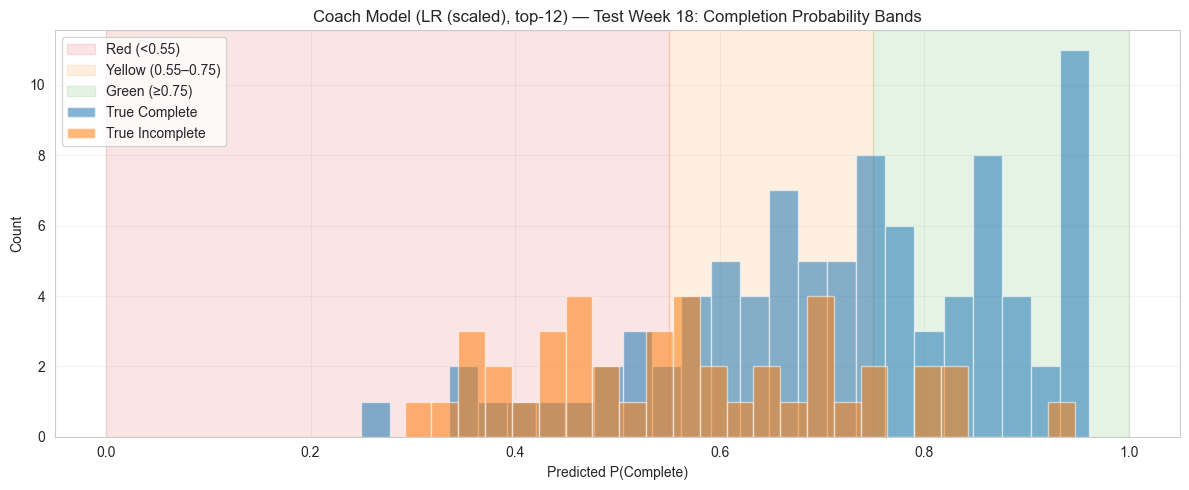

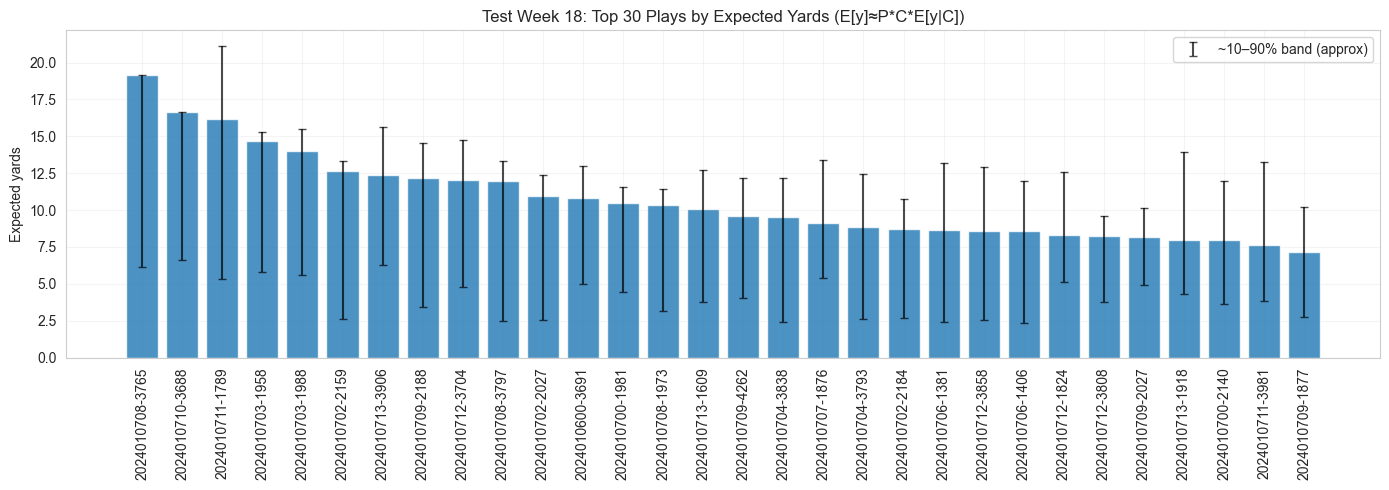

In [87]:
# Choose which classifier output to present to coaches:
# proba_te (best from full_onehot) OR proba_te_top (coach simplified)
# Here: coach simplified top-features bucketed model:
proba_present = proba_te_top
X_present = X_te_b_top  # aligned with that model
clf_present_name = f"Coach Model ({best_name_top}, top-{len(top_features)})"

# For expected yards outputs:
# Use completion probability from coach model + yards|complete mean/quantiles from regression models (full features)
# Note: regression predictions are only defined for completed-pass rows in test_c.
# We'll map them back to test plays; incompletes will have NaNs for E[yards|complete].
idx_test_all = model_data.loc[test_mask].index
idx_test_comp = model_data.loc[test_c].index

df_out = model_data.loc[test_mask, ["game_id", "play_id", WEEK_COL]].copy()
df_out["p_complete"] = proba_present
df_out["color"] = df_out["p_complete"].apply(lambda p: "Green" if p >= 0.75 else ("Yellow" if p >= 0.55 else "Red"))

# Create placeholders for yards|complete predictions, fill only for completed subset
df_out["eyards_given_complete_mean"] = np.nan
df_out["eyards_given_complete_p10"] = np.nan
df_out["eyards_given_complete_p90"] = np.nan
df_out.loc[idx_test_comp, "eyards_given_complete_mean"] = pred_te_mean
df_out.loc[idx_test_comp, "eyards_given_complete_p10"] = pred_te_lo
df_out.loc[idx_test_comp, "eyards_given_complete_p90"] = pred_te_hi

# Expected yards metric (available for all plays: use mean E[yards|complete] when missing -> 0)
df_out["eyards_given_complete_mean_filled"] = df_out["eyards_given_complete_mean"].fillna(0.0)
df_out["expected_yards"] = df_out["p_complete"] * df_out["eyards_given_complete_mean_filled"]

# Uncertainty band (approx)
df_out["expected_yards_p10"] = df_out["p_complete"] * df_out["eyards_given_complete_p10"].fillna(0.0)
df_out["expected_yards_p90"] = df_out["p_complete"] * df_out["eyards_given_complete_p90"].fillna(0.0)

# Explosive probability (approx: P(complete)*P(explosive|complete); only defined where yards model exists)
df_out["p_explosive_given_complete"] = np.nan
df_out.loc[idx_test_comp, "p_explosive_given_complete"] = proba_exp_te
df_out["p_explosive"] = df_out["p_complete"] * df_out["p_explosive_given_complete"].fillna(0.0)

print(df_out.head(10))

# --- Visualization: probability bands on test week ---
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.set_title(f"{clf_present_name} — Test Week {test_week}: Completion Probability Bands")

# shade bands
ax.axvspan(0.00, 0.55, color="#d62728", alpha=0.12, label="Red (<0.55)")
ax.axvspan(0.55, 0.75, color="#ff7f0e", alpha=0.12, label="Yellow (0.55–0.75)")
ax.axvspan(0.75, 1.00, color="#2ca02c", alpha=0.12, label="Green (≥0.75)")

# hist by true label (complete vs incomplete)
mask_complete_test = (y_te == 1)
ax.hist(df_out.loc[mask_complete_test.values, "p_complete"], bins=25, alpha=0.55, label="True Complete")
ax.hist(df_out.loc[~mask_complete_test.values, "p_complete"], bins=25, alpha=0.55, label="True Incomplete")

ax.set_xlabel("Predicted P(Complete)")
ax.set_ylabel("Count")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# --- Visualization: expected yards with uncertainty (show top 30 plays by expected yards) ---
df_plot = df_out.sort_values("expected_yards", ascending=False).head(30).copy()
x = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title(f"Test Week {test_week}: Top 30 Plays by Expected Yards (E[y]≈P*C*E[y|C])")

ax.bar(x, df_plot["expected_yards"], alpha=0.8)
ax.errorbar(
    x,
    df_plot["expected_yards"],
    yerr=[
        (df_plot["expected_yards"] - df_plot["expected_yards_p10"]).clip(lower=0),
        (df_plot["expected_yards_p90"] - df_plot["expected_yards"]).clip(lower=0),
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.7,
    label="~10–90% band (approx)"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{int(r.game_id)}-{int(r.play_id)}" for r in df_plot.itertuples()], rotation=90)
ax.set_ylabel("Expected yards")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Spatial Analysis:

STEP 3: ADVANCED SPATIAL ANALYSIS


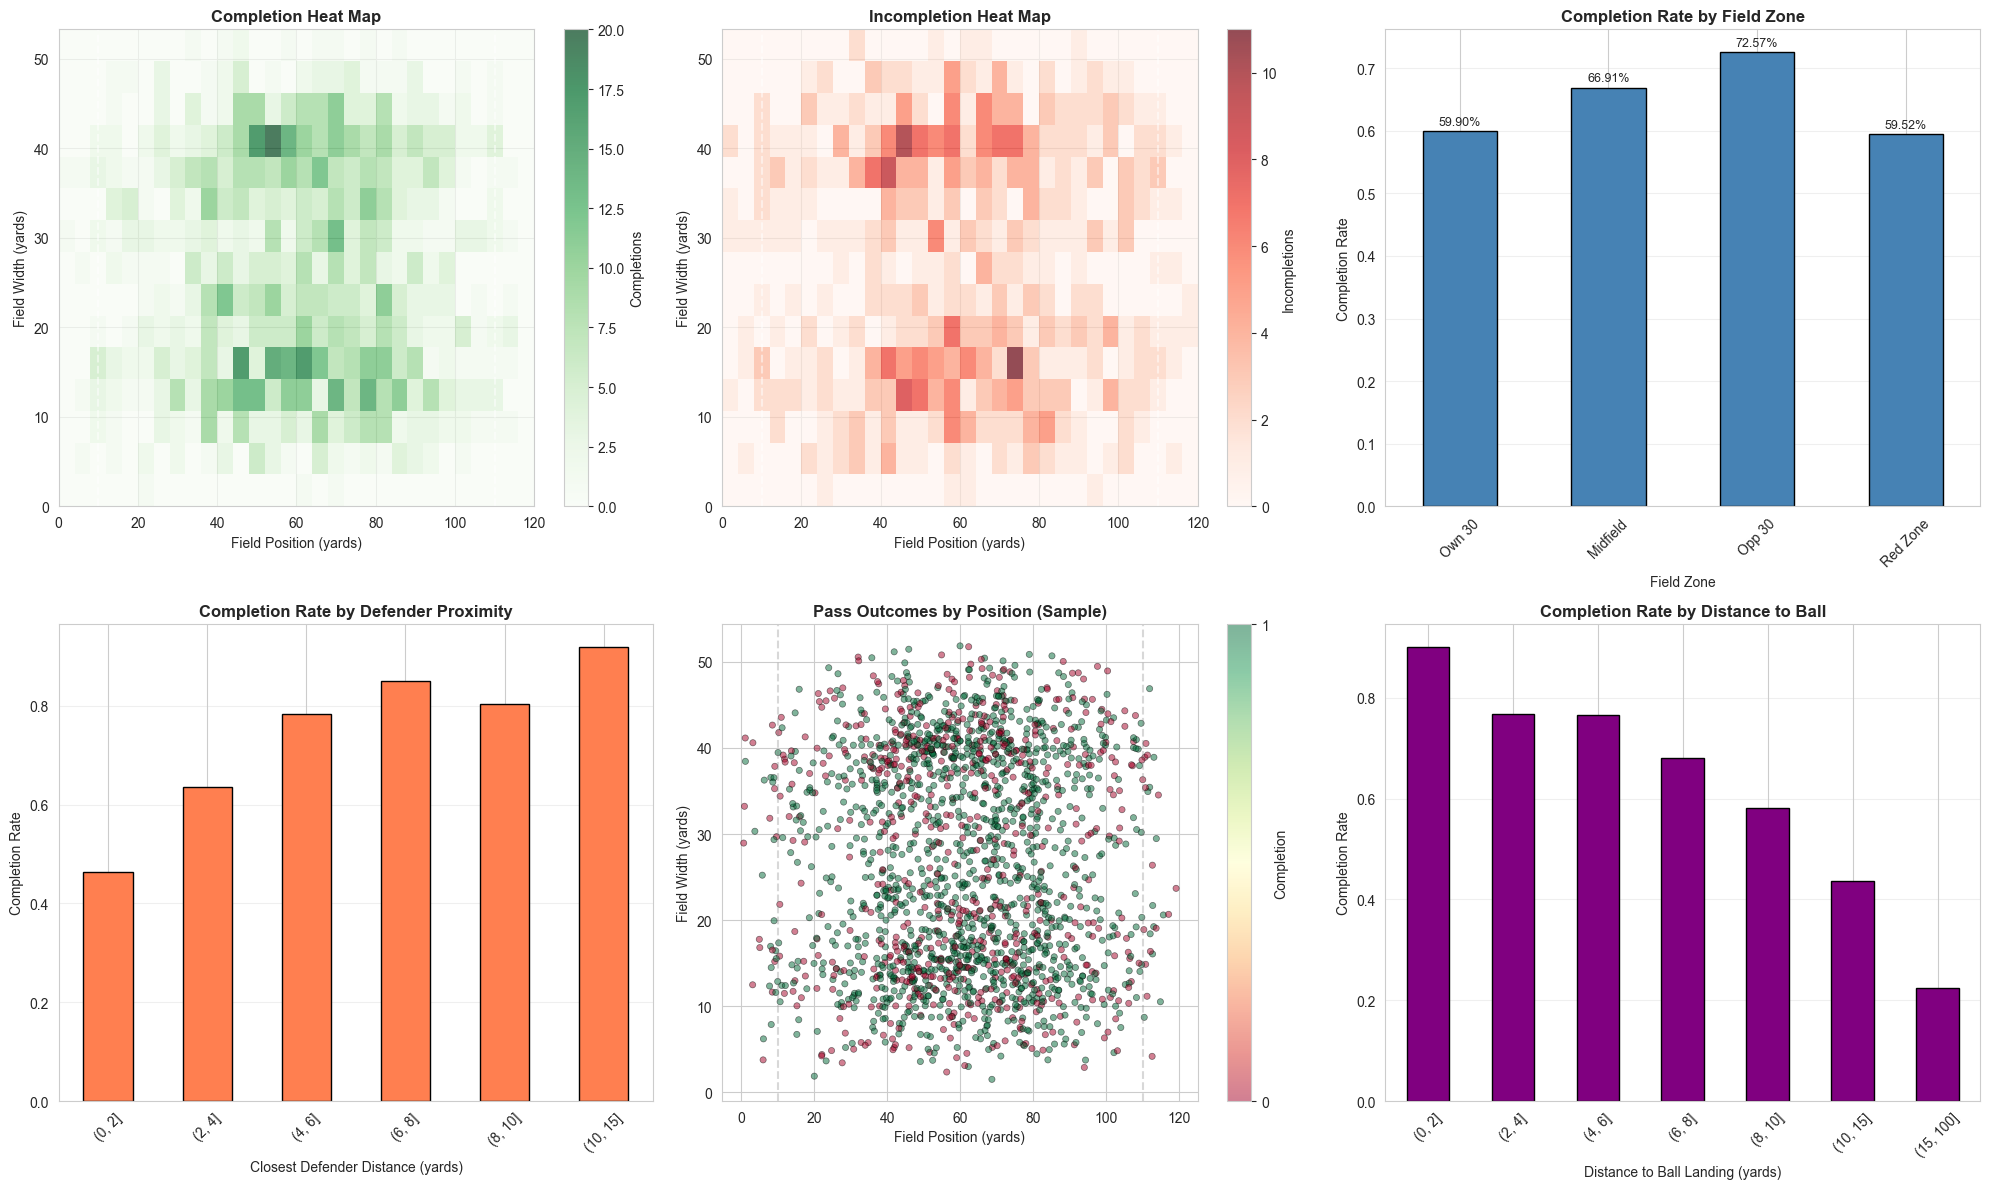


Saved spatial_analysis.png

SPATIAL ANALYSIS INSIGHTS

Completion Rate by Field Zone:
                mean  count
field_zone                 
Own 30      0.599010    202
Midfield    0.669118    816
Opp 30      0.725694    864
Red Zone    0.595238    252

Completion Rate by Defender Proximity:
                        mean  count
defender_proximity                 
(0, 2]              0.464413    562
(2, 4]              0.635750    593
(4, 6]              0.784091    440
(6, 8]              0.851064    235
(8, 10]             0.804511    133
(10, 15]            0.919463    149


In [88]:
# ============================================================================
# STEP 3: ADVANCED SPATIAL ANALYSIS
# ============================================================================

print("="*80)
print("STEP 3: ADVANCED SPATIAL ANALYSIS")
print("="*80)

# Create spatial visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Completion Heat Map by Field Position
ax1 = plt.subplot(2, 3, 1)
completed_plays = model_data[model_data['is_completion'] == 1]
incomplete_plays = model_data[model_data['is_completion'] == 0]

# Create 2D histogram for completions
h_complete = ax1.hist2d(completed_plays['receiver_x'], completed_plays['receiver_y'], 
                         bins=[30, 15], cmap='Greens', alpha=0.7, range=[[0, 120], [0, 53.3]])
ax1.set_xlabel('Field Position (yards)', fontsize=10)
ax1.set_ylabel('Field Width (yards)', fontsize=10)
ax1.set_title('Completion Heat Map', fontsize=12, fontweight='bold')
ax1.axvline(x=10, color='white', linestyle='--', alpha=0.5, label='End Zone')
ax1.axvline(x=110, color='white', linestyle='--', alpha=0.5)
plt.colorbar(h_complete[3], ax=ax1, label='Completions')

# 2. Incompletion Heat Map
ax2 = plt.subplot(2, 3, 2)
h_incomplete = ax2.hist2d(incomplete_plays['receiver_x'], incomplete_plays['receiver_y'], 
                           bins=[30, 15], cmap='Reds', alpha=0.7, range=[[0, 120], [0, 53.3]])
ax2.set_xlabel('Field Position (yards)', fontsize=10)
ax2.set_ylabel('Field Width (yards)', fontsize=10)
ax2.set_title('Incompletion Heat Map', fontsize=12, fontweight='bold')
ax2.axvline(x=10, color='white', linestyle='--', alpha=0.5)
ax2.axvline(x=110, color='white', linestyle='--', alpha=0.5)
plt.colorbar(h_incomplete[3], ax=ax2, label='Incompletions')

# 3. Completion Rate by Field Zone
ax3 = plt.subplot(2, 3, 3)
model_data['field_zone'] = pd.cut(model_data['receiver_x'], bins=[0, 30, 60, 90, 120], 
                                    labels=['Own 30', 'Midfield', 'Opp 30', 'Red Zone'])
zone_completion = model_data.groupby('field_zone')['is_completion'].agg(['mean', 'count'])
zone_completion['mean'].plot(kind='bar', ax=ax3, color='steelblue', edgecolor='black')
ax3.set_xlabel('Field Zone', fontsize=10)
ax3.set_ylabel('Completion Rate', fontsize=10)
ax3.set_title('Completion Rate by Field Zone', fontsize=12, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(zone_completion['mean']):
    ax3.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

# 4. Defender Proximity Analysis
ax4 = plt.subplot(2, 3, 4)
proximity_bins = [0, 2, 4, 6, 8, 10, 15, 50]
model_data['defender_proximity'] = pd.cut(model_data['closest_defender_dist'], bins=proximity_bins)
proximity_completion = model_data.groupby('defender_proximity')['is_completion'].agg(['mean', 'count'])
proximity_completion = proximity_completion[proximity_completion['count'] > 50]
proximity_completion['mean'].plot(kind='bar', ax=ax4, color='coral', edgecolor='black')
ax4.set_xlabel('Closest Defender Distance (yards)', fontsize=10)
ax4.set_ylabel('Completion Rate', fontsize=10)
ax4.set_title('Completion Rate by Defender Proximity', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)
ax4.grid(axis='y', alpha=0.3)

# 5. Coverage Zones - Scatter Plot
ax5 = plt.subplot(2, 3, 5)
sample_data = model_data.sample(min(2000, len(model_data)), random_state=42)
scatter = ax5.scatter(sample_data['receiver_x'], sample_data['receiver_y'], 
                      c=sample_data['is_completion'], cmap='RdYlGn', 
                      alpha=0.5, s=20, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Field Position (yards)', fontsize=10)
ax5.set_ylabel('Field Width (yards)', fontsize=10)
ax5.set_title('Pass Outcomes by Position (Sample)', fontsize=12, fontweight='bold')
ax5.axvline(x=10, color='gray', linestyle='--', alpha=0.3)
ax5.axvline(x=110, color='gray', linestyle='--', alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='Completion', ticks=[0, 1])

# 6. Distance to Ball Landing vs Completion
ax6 = plt.subplot(2, 3, 6)
dist_bins = [0, 2, 4, 6, 8, 10, 15, 100]
model_data['dist_to_ball_bin'] = pd.cut(model_data['dist_to_ball_land'], bins=dist_bins)
dist_completion = model_data.groupby('dist_to_ball_bin')['is_completion'].agg(['mean', 'count'])
dist_completion = dist_completion[dist_completion['count'] > 50]
dist_completion['mean'].plot(kind='bar', ax=ax6, color='purple', edgecolor='black')
ax6.set_xlabel('Distance to Ball Landing (yards)', fontsize=10)
ax6.set_ylabel('Completion Rate', fontsize=10)
ax6.set_title('Completion Rate by Distance to Ball', fontsize=12, fontweight='bold')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Two-Minute Drill/spatial_analysis_two_minute.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved spatial_analysis.png")

# Print spatial insights
print("\n" + "="*60)
print("SPATIAL ANALYSIS INSIGHTS")
print("="*60)
print("\nCompletion Rate by Field Zone:")
print(zone_completion.to_string())
print("\nCompletion Rate by Defender Proximity:")
print(proximity_completion.to_string())

STEP 4: Temporal ANALYSIS
✓ Saved temporal_analysis_2min_drill.png


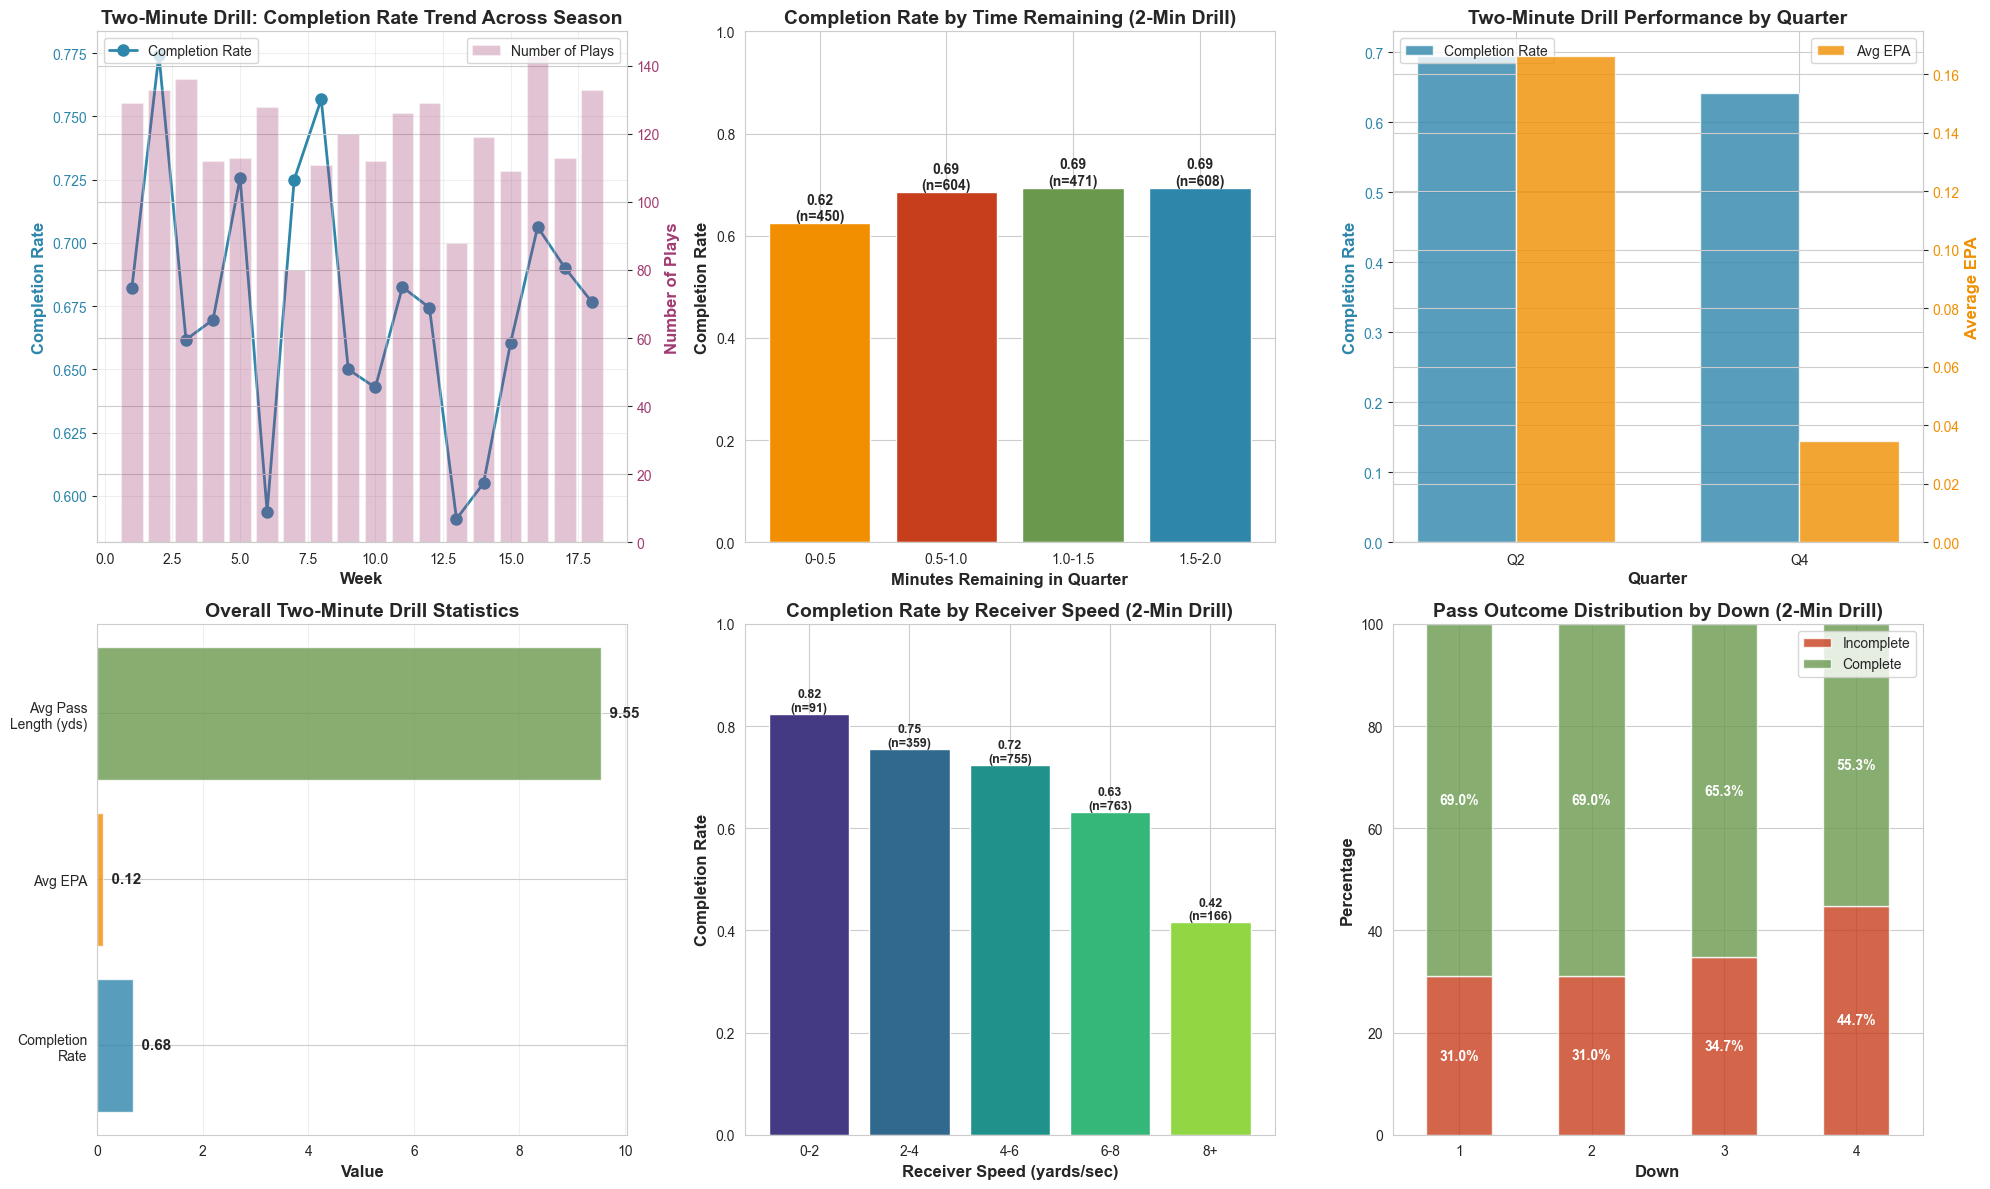


KEY TEMPORAL INSIGHTS (TWO-MINUTE DRILL)

1. Weekly Trends:
   - Highest completion rate: Week 2 (0.774)
   - Lowest completion rate: Week 13 (0.591)
   - Most active week: Week 16 (143 plays)

2. Time Pressure:
   - Completion rate with <30 seconds: 0.624
   - Completion rate with 1.5-2 minutes: 0.694

3. Quarter Analysis:
   - Q2: 0.695 completion rate, 0.166 EPA (1385 plays)
   - Q4: 0.642 completion rate, 0.035 EPA (749 plays)

4. Receiver Speed Impact:
   - Highest completion with speed: 0-2 yds/sec (0.824)
   - Lowest completion with speed: 8+ yds/sec (0.416)


In [89]:
# ============================================================================
# STEP 4: Temporal ANALYSIS
# ============================================================================

print("="*80)
print("STEP 4: Temporal ANALYSIS")
print("="*80)


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

# Create comprehensive temporal analysis
fig = plt.figure(figsize=(20, 12))

# 1. Completion Rate Trend Across Season
ax1 = plt.subplot(2, 3, 1)
weekly_stats = model_data.groupby('week').agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()
weekly_stats.columns = ['week', 'completion_rate', 'num_plays']

ax1_twin = ax1.twinx()
ax1.plot(weekly_stats['week'], weekly_stats['completion_rate'], 
         marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Completion Rate')
ax1_twin.bar(weekly_stats['week'], weekly_stats['num_plays'], 
             alpha=0.3, color='#A23B72', label='Number of Plays')

ax1.set_xlabel('Week', fontsize=12, fontweight='bold')
ax1.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='#2E86AB')
ax1_twin.set_ylabel('Number of Plays', fontsize=12, fontweight='bold', color='#A23B72')
ax1.set_title('Two-Minute Drill: Completion Rate Trend Across Season', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2E86AB')
ax1_twin.tick_params(axis='y', labelcolor='#A23B72')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Completion Rate by Game Clock
ax2 = plt.subplot(2, 3, 2)
# Convert game_clock to minutes remaining
def parse_game_clock(clock_str):
    try:
        parts = clock_str.split(':')
        return int(parts[0]) + int(parts[1])/60
    except:
        return np.nan

model_data['minutes_remaining'] = model_data['game_clock'].apply(parse_game_clock)
model_data['time_bin'] = pd.cut(model_data['minutes_remaining'], 
                                 bins=[0, 0.5, 1.0, 1.5, 2.0], 
                                 labels=['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0'])

time_stats = model_data.groupby('time_bin', observed=True).agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()

bars = ax2.bar(range(len(time_stats)), time_stats['is_completion'], 
               color=['#F18F01', '#C73E1D', '#6A994E', '#2E86AB'])
ax2.set_xticks(range(len(time_stats)))
ax2.set_xticklabels(time_stats['time_bin'], rotation=0)
ax2.set_xlabel('Minutes Remaining in Quarter', fontsize=12, fontweight='bold')
ax2.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax2.set_title('Completion Rate by Time Remaining (2-Min Drill)', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, (bar, val, count) in enumerate(zip(bars, time_stats['is_completion'], time_stats['play_id'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={count})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Performance by Quarter
ax3 = plt.subplot(2, 3, 3)
quarter_stats = model_data.groupby('quarter').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).reset_index()

x = np.arange(len(quarter_stats))
width = 0.35

bars1 = ax3.bar(x - width/2, quarter_stats['is_completion'], width, 
                label='Completion Rate', color='#2E86AB', alpha=0.8)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, quarter_stats['expected_points_added'], width,
                     label='Avg EPA', color='#F18F01', alpha=0.8)

ax3.set_xlabel('Quarter', fontsize=12, fontweight='bold')
ax3.set_ylabel('Completion Rate', fontsize=12, fontweight='bold', color='#2E86AB')
ax3_twin.set_ylabel('Average EPA', fontsize=12, fontweight='bold', color='#F18F01')
ax3.set_title('Two-Minute Drill Performance by Quarter', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Q{int(q)}' for q in quarter_stats['quarter']])
ax3.tick_params(axis='y', labelcolor='#2E86AB')
ax3_twin.tick_params(axis='y', labelcolor='#F18F01')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. Two-Minute Drill Statistics (Since all plays are 2-min drill, show overall stats)
ax4 = plt.subplot(2, 3, 4)
overall_stats = pd.DataFrame({
    'Metric': ['Completion\nRate', 'Avg EPA', 'Avg Pass\nLength (yds)'],
    'Value': [
        model_data['is_completion'].mean(),
        model_data['expected_points_added'].mean(),
        model_data['pass_length'].mean()
    ]
})

colors = ['#2E86AB', '#F18F01', '#6A994E']
bars = ax4.barh(overall_stats['Metric'], overall_stats['Value'], color=colors, alpha=0.8)

ax4.set_xlabel('Value', fontsize=12, fontweight='bold')
ax4.set_title('Overall Two-Minute Drill Statistics', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, overall_stats['Value']):
    label = f'{val:.2f}'
    ax4.text(val, bar.get_y() + bar.get_height()/2., f'  {label}',
             ha='left', va='center', fontsize=11, fontweight='bold')

# 5. Completion Rate by Receiver Speed
ax5 = plt.subplot(2, 3, 5)
model_data['speed_bin'] = pd.cut(model_data['receiver_speed'], 
                                  bins=[0, 2, 4, 6, 8, 15],
                                  labels=['0-2', '2-4', '4-6', '6-8', '8+'])

speed_stats = model_data.groupby('speed_bin', observed=True).agg({
    'is_completion': 'mean',
    'play_id': 'count'
}).reset_index()

bars = ax5.bar(range(len(speed_stats)), speed_stats['is_completion'],
               color=sns.color_palette("viridis", len(speed_stats)))
ax5.set_xticks(range(len(speed_stats)))
ax5.set_xticklabels(speed_stats['speed_bin'], rotation=0)
ax5.set_xlabel('Receiver Speed (yards/sec)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Completion Rate', fontsize=12, fontweight='bold')
ax5.set_title('Completion Rate by Receiver Speed (2-Min Drill)', fontsize=14, fontweight='bold')
ax5.set_ylim([0, 1])

# Add value labels
for bar, val, count in zip(bars, speed_stats['is_completion'], speed_stats['play_id']):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={count})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Completion vs Incompletion by Down
ax6 = plt.subplot(2, 3, 6)
down_stats = model_data.groupby(['down', 'is_completion']).size().unstack(fill_value=0)
down_stats_pct = down_stats.div(down_stats.sum(axis=1), axis=0) * 100

down_stats_pct.plot(kind='bar', stacked=True, ax=ax6, 
                    color=['#C73E1D', '#6A994E'], alpha=0.8)
ax6.set_xlabel('Down', fontsize=12, fontweight='bold')
ax6.set_ylabel('Percentage', fontsize=12, fontweight='bold')
ax6.set_title('Pass Outcome Distribution by Down (2-Min Drill)', fontsize=14, fontweight='bold')
ax6.set_xticklabels([f'{int(d)}' for d in down_stats_pct.index], rotation=0)
ax6.legend(['Incomplete', 'Complete'], loc='upper right')
ax6.set_ylim([0, 100])

# Add percentage labels
for i, down in enumerate(down_stats_pct.index):
    incomplete_pct = down_stats_pct.loc[down, 0]
    complete_pct = down_stats_pct.loc[down, 1]
    
    # Label for incomplete
    ax6.text(i, incomplete_pct/2, f'{incomplete_pct:.1f}%',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    
    # Label for complete
    ax6.text(i, incomplete_pct + complete_pct/2, f'{complete_pct:.1f}%',
             ha='center', va='center', fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('Two-Minute Drill/temporal_analysis_2min_drill.png', dpi=300, bbox_inches='tight')
print("✓ Saved temporal_analysis_2min_drill.png")
plt.show()

# Print key insights
print("\n" + "="*60)
print("KEY TEMPORAL INSIGHTS (TWO-MINUTE DRILL)")
print("="*60)

print(f"\n1. Weekly Trends:")
print(f"   - Highest completion rate: Week {weekly_stats.loc[weekly_stats['completion_rate'].idxmax(), 'week']:.0f} ({weekly_stats['completion_rate'].max():.3f})")
print(f"   - Lowest completion rate: Week {weekly_stats.loc[weekly_stats['completion_rate'].idxmin(), 'week']:.0f} ({weekly_stats['completion_rate'].min():.3f})")
print(f"   - Most active week: Week {weekly_stats.loc[weekly_stats['num_plays'].idxmax(), 'week']:.0f} ({weekly_stats['num_plays'].max():.0f} plays)")

print(f"\n2. Time Pressure:")
print(f"   - Completion rate with <30 seconds: {time_stats[time_stats['time_bin'] == '0-0.5']['is_completion'].values[0]:.3f}" if len(time_stats[time_stats['time_bin'] == '0-0.5']) > 0 else "   - No plays with <30 seconds")
print(f"   - Completion rate with 1.5-2 minutes: {time_stats[time_stats['time_bin'] == '1.5-2.0']['is_completion'].values[0]:.3f}" if len(time_stats[time_stats['time_bin'] == '1.5-2.0']) > 0 else "   - No plays with 1.5-2 minutes")

print(f"\n3. Quarter Analysis:")
for _, row in quarter_stats.iterrows():
    print(f"   - Q{int(row['quarter'])}: {row['is_completion']:.3f} completion rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print(f"\n4. Receiver Speed Impact:")
print(f"   - Highest completion with speed: {speed_stats.loc[speed_stats['is_completion'].idxmax(), 'speed_bin']} yds/sec ({speed_stats['is_completion'].max():.3f})")
print(f"   - Lowest completion with speed: {speed_stats.loc[speed_stats['is_completion'].idxmin(), 'speed_bin']} yds/sec ({speed_stats['is_completion'].min():.3f})")

In [90]:
# ============================================================================
# STEP 5: NETWORK ANALYSIS
# ============================================================================

print("="*80)
print("STEP 5: NETWORK ANALYSIS")
print("="*80)

# Extract passer information from play descriptions
def extract_passer_name(description):
    """Extract passer name from play description"""
    if pd.isna(description):
        return 'Unknown'
    # Pattern: "Name pass" or "Initial.Name pass"
    import re
    match = re.search(r'([A-Z]\.[A-Z][a-z]+|[A-Z][a-z]+\.[A-Z][a-z]+)\s+pass', description)
    if match:
        return match.group(1)
    return 'Unknown'

def extract_receiver_name(description):
    """Extract receiver name from play description"""
    if pd.isna(description):
        return 'Unknown'
    import re
    # Pattern: "to Name" or "to Initial.Name"
    match = re.search(r'to\s+([A-Z]\.[A-Z][a-z]+|[A-Z][a-z]+)', description)
    if match:
        return match.group(1)
    return 'Unknown'

model_data['passer_name'] = model_data['play_description'].apply(extract_passer_name)
model_data['receiver_name'] = model_data['play_description'].apply(extract_receiver_name)

# QB-Receiver Connection Analysis
qb_receiver_stats = model_data.groupby(['passer_name', 'receiver_name']).agg({
    'is_completion': ['sum', 'count', 'mean'],
    'expected_points_added': 'sum',
    'yards_gained': 'sum'
}).reset_index()

qb_receiver_stats.columns = ['passer', 'receiver', 'completions', 'targets', 
                              'completion_rate', 'total_epa', 'total_yards']

# Filter for meaningful connections (at least 10 targets)
qb_receiver_stats = qb_receiver_stats[qb_receiver_stats['targets'] >= 10]
qb_receiver_stats = qb_receiver_stats.sort_values('total_epa', ascending=False)

print("\n" + "="*60)
print("TOP 20 QB-RECEIVER CONNECTIONS (by EPA)")
print("="*60)
print(qb_receiver_stats.head(20).to_string(index=False))

# Team-level analysis
team_offense_stats = model_data.groupby('possession_team').agg({
    'is_completion': ['mean', 'count'],
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'pass_length': 'mean'
}).round(3)

team_offense_stats.columns = ['completion_rate', 'plays', 'avg_epa', 'avg_yards', 'avg_pass_length']
team_offense_stats = team_offense_stats.sort_values('avg_epa', ascending=False)

print("\n" + "="*60)
print("TEAM OFFENSIVE EFFICIENCY")
print("="*60)
print(team_offense_stats.head(15).to_string())

# Coverage effectiveness by team
team_defense_stats = model_data.groupby('defensive_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean'
}).round(3)

team_defense_stats.columns = ['completion_rate_allowed', 'avg_epa_allowed', 'avg_yards_allowed']
team_defense_stats = team_defense_stats.sort_values('avg_epa_allowed')

print("\n" + "="*60)
print("TEAM DEFENSIVE EFFICIENCY")
print("="*60)
print(team_defense_stats.head(15).to_string())

# Route combination analysis
route_coverage_matrix = pd.crosstab(
    model_data['route_of_targeted_receiver'].fillna('Unknown'),
    model_data['team_coverage_type'].fillna('Unknown'),
    values=model_data['is_completion'],
    aggfunc='mean'
)

print("\n" + "="*60)
print("ROUTE vs COVERAGE EFFECTIVENESS MATRIX")
print("="*60)
print(route_coverage_matrix.round(3).to_string())

# Save network analysis data
qb_receiver_stats.to_csv('Two-Minute Drill/qb_receiver_connections_two_minute.csv', index=False)
team_offense_stats.to_csv('Two-Minute Drill/team_offense_stats_two_minute.csv')
team_defense_stats.to_csv('Two-Minute Drill/team_defense_stats_two_minute.csv')
route_coverage_matrix.to_csv('Two-Minute Drill/route_coverage_matrix_two_minute.csv')

print("\n\nSaved network analysis files:")
print("  - qb_receiver_connections.csv")
print("  - team_offense_stats.csv")
print("  - team_defense_stats.csv")
print("  - route_coverage_matrix.csv")

STEP 5: NETWORK ANALYSIS

TOP 20 QB-RECEIVER CONNECTIONS (by EPA)
      passer  receiver  completions  targets  completion_rate  total_epa  total_yards
T.Tagovailoa    T.Hill           13       15         0.866667  18.651753          158
      J.Goff      A.St           20       29         0.689655  15.834133          245
  B.Mayfield  C.Godwin           13       21         0.619048  15.345379          212
    C.Stroud    N.Dell            8       11         0.727273  14.664397          148
     G.Smith T.Lockett           15       20         0.750000  10.648899          198
  M.Stafford  T.Atwell            8       10         0.800000  10.610778          112
     J.Allen   S.Diggs           14       17         0.823529   9.747994          176
  D.Prescott    C.Lamb           16       19         0.842105   9.693748          182
  M.Stafford   P.Nacua            9       17         0.529412   9.377972          136
     J.Hurts   A.Brown           13       19         0.684211   8.524759  

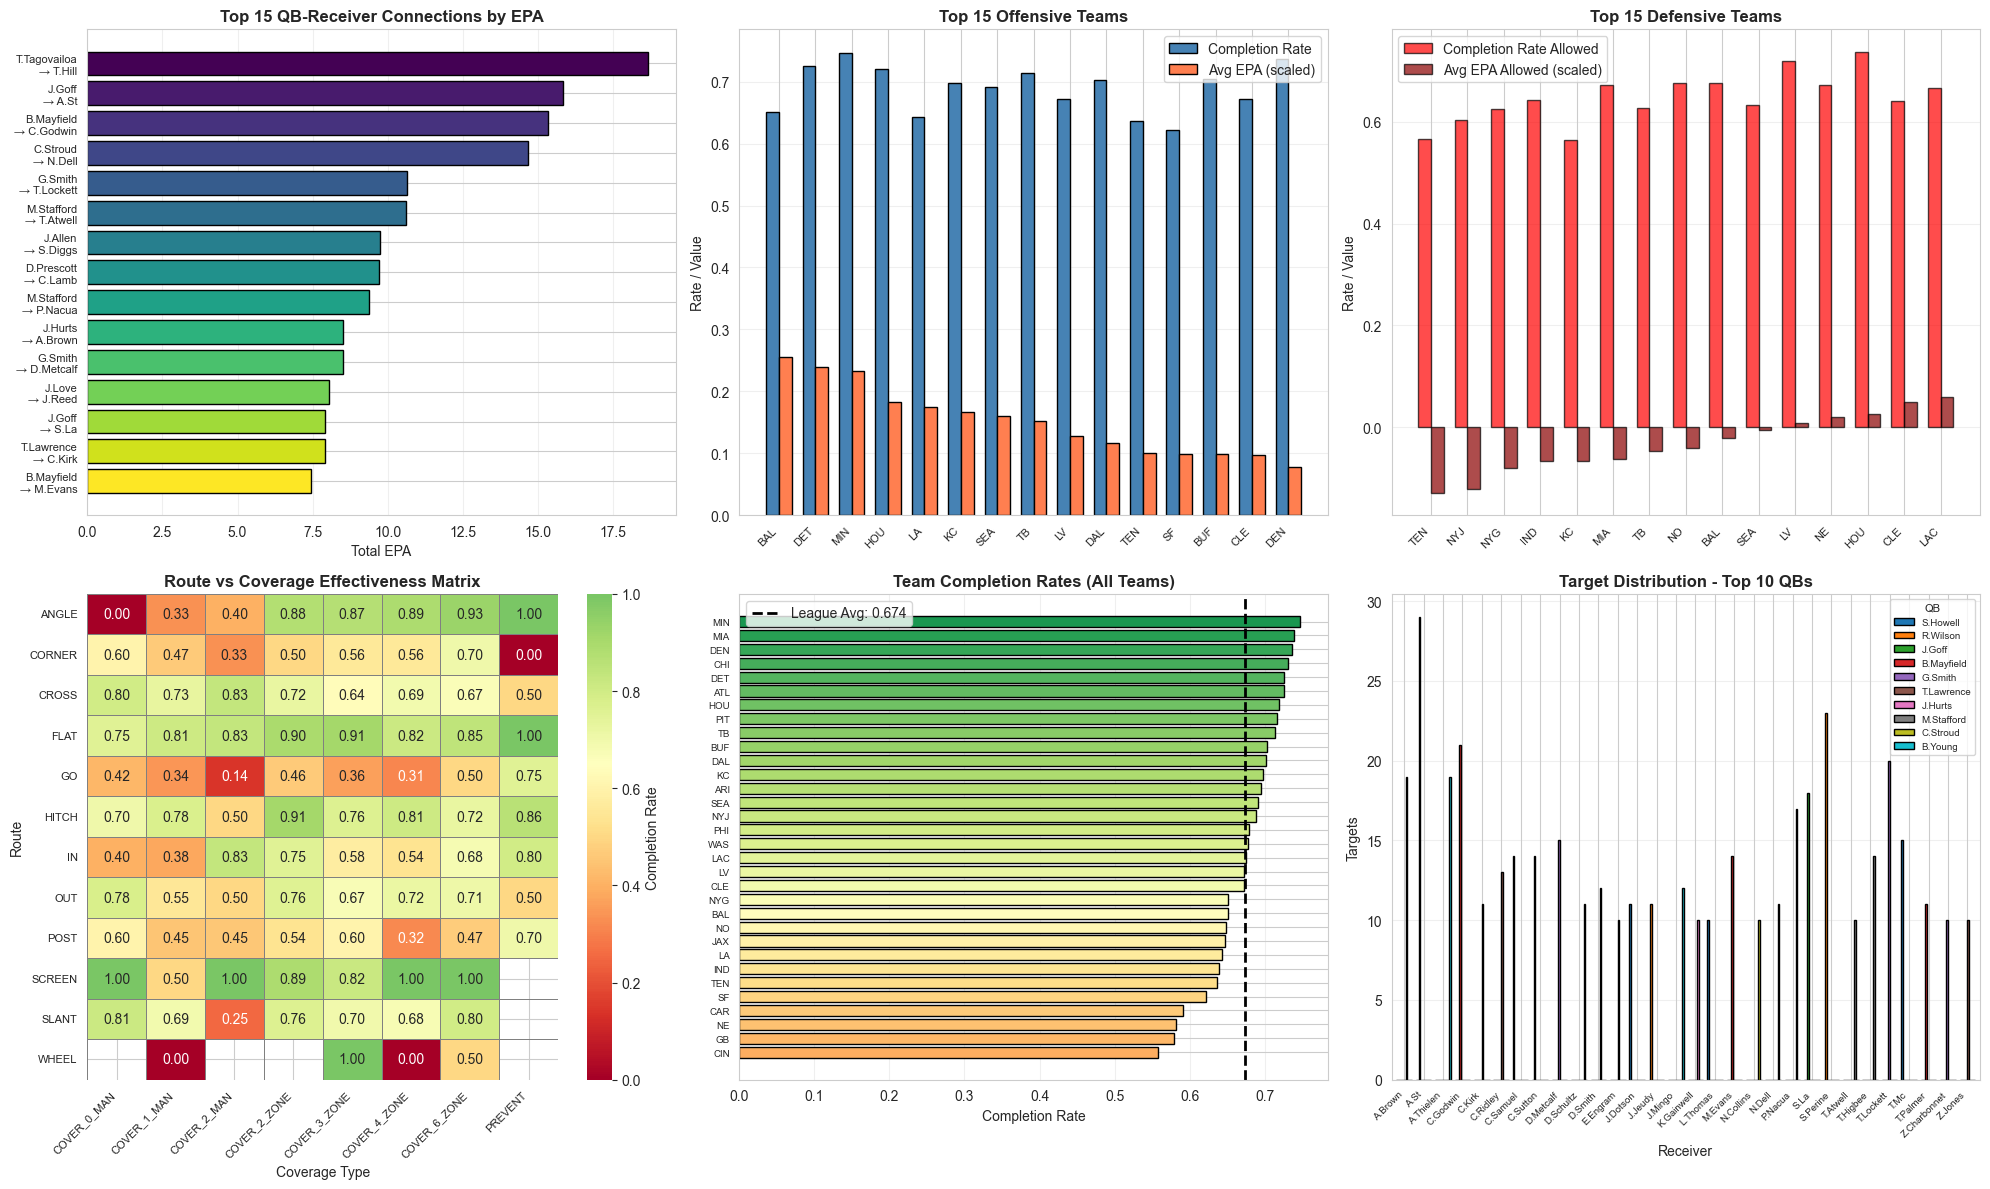


Saved network_analysis.png


In [91]:
# Create network analysis visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Top QB-Receiver Connections
ax1 = plt.subplot(2, 3, 1)
top_connections = qb_receiver_stats.head(15).copy()
top_connections['connection'] = top_connections['passer'] + '\n→ ' + top_connections['receiver']
colors = plt.cm.viridis(np.linspace(0, 1, len(top_connections)))
bars = ax1.barh(range(len(top_connections)), top_connections['total_epa'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_connections)))
ax1.set_yticklabels(top_connections['connection'], fontsize=8)
ax1.set_xlabel('Total EPA', fontsize=10)
ax1.set_title('Top 15 QB-Receiver Connections by EPA', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Team Offensive Efficiency
ax2 = plt.subplot(2, 3, 2)
top_offense = team_offense_stats.head(15)
x = np.arange(len(top_offense))
width = 0.35
ax2.bar(x - width/2, top_offense['completion_rate'], width, label='Completion Rate', 
        color='steelblue', edgecolor='black')
ax2.bar(x + width/2, top_offense['avg_epa']/2, width, label='Avg EPA (scaled)', 
        color='coral', edgecolor='black')
ax2.set_ylabel('Rate / Value', fontsize=10)
ax2.set_title('Top 15 Offensive Teams', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(top_offense.index, rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Team Defensive Efficiency
ax3 = plt.subplot(2, 3, 3)
top_defense = team_defense_stats.head(15)
x = np.arange(len(top_defense))
ax3.bar(x - width/2, top_defense['completion_rate_allowed'], width, 
        label='Completion Rate Allowed', color='red', alpha=0.7, edgecolor='black')
ax3.bar(x + width/2, top_defense['avg_epa_allowed']/2, width, 
        label='Avg EPA Allowed (scaled)', color='darkred', alpha=0.7, edgecolor='black')
ax3.set_ylabel('Rate / Value', fontsize=10)
ax3.set_title('Top 15 Defensive Teams', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top_defense.index, rotation=45, ha='right', fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Route Effectiveness Heatmap
ax4 = plt.subplot(2, 3, 4)
route_coverage_clean = route_coverage_matrix.iloc[:12, :8]  # Remove Unknown and limit size
sns.heatmap(route_coverage_clean, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0.65, ax=ax4, cbar_kws={'label': 'Completion Rate'}, 
            linewidths=0.5, linecolor='gray')
ax4.set_xlabel('Coverage Type', fontsize=10)
ax4.set_ylabel('Route', fontsize=10)
ax4.set_title('Route vs Coverage Effectiveness Matrix', fontsize=12, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=8)

# 5. Completion Rate Distribution by Team
ax5 = plt.subplot(2, 3, 5)
team_completion_dist = model_data.groupby('possession_team')['is_completion'].mean().sort_values()
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(team_completion_dist)))
ax5.barh(range(len(team_completion_dist)), team_completion_dist.values, 
         color=colors_gradient, edgecolor='black')
ax5.set_yticks(range(len(team_completion_dist)))
ax5.set_yticklabels(team_completion_dist.index, fontsize=7)
ax5.set_xlabel('Completion Rate', fontsize=10)
ax5.set_title('Team Completion Rates (All Teams)', fontsize=12, fontweight='bold')
ax5.axvline(x=team_completion_dist.mean(), color='black', linestyle='--', 
            linewidth=2, label=f'League Avg: {team_completion_dist.mean():.3f}')
ax5.legend()
ax5.grid(axis='x', alpha=0.3)

# 6. Target Distribution for Top QBs
ax6 = plt.subplot(2, 3, 6)
top_qbs = qb_receiver_stats.groupby('passer')['targets'].sum().nlargest(10)
qb_target_dist = qb_receiver_stats[qb_receiver_stats['passer'].isin(top_qbs.index)]
qb_pivot = qb_target_dist.pivot_table(values='targets', index='passer', 
                                       columns='receiver', fill_value=0)
qb_pivot_top = qb_pivot.loc[top_qbs.index]
# Get top 5 receivers for each QB
qb_pivot_top_5 = qb_pivot_top.apply(lambda x: x.nlargest(5), axis=1).fillna(0)
qb_pivot_top_5.T.plot(kind='bar', ax=ax6, width=0.8, edgecolor='black')
ax6.set_xlabel('Receiver', fontsize=10)
ax6.set_ylabel('Targets', fontsize=10)
ax6.set_title('Target Distribution - Top 10 QBs', fontsize=12, fontweight='bold')
ax6.legend(title='QB', fontsize=7, title_fontsize=8, loc='upper right')
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Two-Minute Drill/network_analysis_two_minute.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved network_analysis.png")

In [92]:
print("="*60)
print("PREPARING INTERACTIVE DASHBOARD DATA (TWO-MINUTE DRILL ONLY)")
print("="*60)

# Filter for two-minute drill plays only
model_data_2min = model_data[model_data['is_two_minute_drill'] == True].copy()
print(f"\nFiltered to {len(model_data_2min)} two-minute drill plays (from {len(model_data)} total plays)")

# Prepare comprehensive data for dashboard
dashboard_data = {}

# 1. Overall Statistics (Two-Minute Drill Only)
dashboard_data['overall_stats'] = {
    'total_plays': len(model_data_2min),
    'completion_rate': model_data_2min['is_completion'].mean(),
    'avg_epa': model_data_2min['expected_points_added'].mean(),
    'avg_pass_length': model_data_2min['pass_length'].mean(),
    'total_weeks': model_data_2min['week'].nunique(),
    'total_games': model_data_2min['game_id'].nunique(),
    'avg_defender_proximity': model_data_2min['closest_defender_dist'].mean(),
    'avg_receiver_speed': model_data_2min['receiver_speed'].mean()
}

# 2. Situation-based Statistics (Quarter breakdown for two-minute drill)
dashboard_data['situation_stats'] = model_data_2min.groupby('quarter').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'play_id': 'count'
}).round(3)

# Add red zone stats (within two-minute drill)
redzone_in = model_data_2min[model_data_2min['is_redzone']].agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
})
redzone_out = model_data_2min[~model_data_2min['is_redzone']].agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
})

dashboard_data['redzone_stats'] = pd.DataFrame({
    'in_redzone': redzone_in,
    'outside_redzone': redzone_out
}).T

# 3. Coverage Type Analysis (Two-Minute Drill)
dashboard_data['coverage_stats'] = model_data_2min.groupby('team_coverage_type').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3).sort_values('is_completion', ascending=False)

# 4. Route Analysis (Two-Minute Drill)
dashboard_data['route_stats'] = model_data_2min.groupby('route_of_targeted_receiver').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'play_id': 'count'
}).round(3).sort_values('is_completion', ascending=False)

# 5. Formation Analysis (Two-Minute Drill)
dashboard_data['formation_stats'] = model_data_2min.groupby('offense_formation').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=False)

# 6. Weekly Trends (Two-Minute Drill)
dashboard_data['weekly_trends'] = model_data_2min.groupby('week').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'pass_length': 'mean',
    'receiver_speed': 'mean',
    'closest_defender_dist': 'mean',
    'play_id': 'count'
}).round(3)

# 7. Team Rankings (Offense - Two-Minute Drill)
dashboard_data['team_offense_rankings'] = model_data_2min.groupby('possession_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=False).head(10)

# 8. Team Rankings (Defense - Two-Minute Drill)
dashboard_data['team_defense_rankings'] = model_data_2min.groupby('defensive_team').agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'yards_gained': 'mean',
    'play_id': 'count'
}).round(3).sort_values('expected_points_added', ascending=True).head(10)

# 9. Defender Proximity Analysis (Two-Minute Drill)
model_data_2min['defender_proximity_bin'] = pd.cut(
    model_data_2min['closest_defender_dist'],
    bins=[0, 2, 5, 10, 15, 100],
    labels=['<2 yds', '2-5 yds', '5-10 yds', '10-15 yds', '15+ yds']
)

dashboard_data['defender_proximity_stats'] = model_data_2min.groupby('defender_proximity_bin', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 10. Speed Analysis (Two-Minute Drill)
model_data_2min['speed_category'] = pd.cut(
    model_data_2min['receiver_speed'],
    bins=[0, 2, 4, 6, 8, 15],
    labels=['Very Slow (0-2)', 'Slow (2-4)', 'Medium (4-6)', 'Fast (6-8)', 'Very Fast (8+)']
)

dashboard_data['speed_stats'] = model_data_2min.groupby('speed_category', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 11. Down and Distance Analysis (Two-Minute Drill)
dashboard_data['down_distance_stats'] = model_data_2min.groupby(['down', 'yards_to_go']).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# 12. Time Remaining Analysis (Two-Minute Drill)
def parse_game_clock(clock_str):
    try:
        parts = str(clock_str).split(':')
        return int(parts[0]) + int(parts[1])/60
    except:
        return np.nan

model_data_2min['minutes_remaining'] = model_data_2min['game_clock'].apply(parse_game_clock)
model_data_2min['time_category'] = pd.cut(
    model_data_2min['minutes_remaining'],
    bins=[0, 0.5, 1.0, 1.5, 2.0],
    labels=['0-30 sec', '30-60 sec', '1-1.5 min', '1.5-2 min']
)

dashboard_data['time_pressure_stats'] = model_data_2min.groupby('time_category', observed=True).agg({
    'is_completion': 'mean',
    'expected_points_added': 'mean',
    'play_id': 'count'
}).round(3)

# Save dashboard data
print("\nCreating structured dashboard tables...")

# Table 1: Overall Metrics
overall_df = pd.DataFrame([dashboard_data['overall_stats']])
overall_df.to_csv('Two-Minute Drill/dashboard_overall_stats_2min.csv', index=False)
print("✓ Saved dashboard_overall_stats_2min.csv")

# Table 2: Coverage Performance
dashboard_data['coverage_stats'].to_csv('Two-Minute Drill/dashboard_coverage_stats_2min.csv')
print("✓ Saved dashboard_coverage_stats_2min.csv")

# Table 3: Route Performance
dashboard_data['route_stats'].to_csv('Two-Minute Drill/dashboard_route_stats_2min.csv')
print("✓ Saved dashboard_route_stats_2min.csv")

# Table 4: Weekly Trends
dashboard_data['weekly_trends'].to_csv('Two-Minute Drill/dashboard_weekly_trends_2min.csv')
print("✓ Saved dashboard_weekly_trends_2min.csv")

# Table 5: Team Offense Rankings
dashboard_data['team_offense_rankings'].to_csv('Two-Minute Drill/dashboard_team_offense_2min.csv')
print("✓ Saved dashboard_team_offense_2min.csv")

# Table 6: Team Defense Rankings
dashboard_data['team_defense_rankings'].to_csv('Two-Minute Drill/dashboard_team_defense_2min.csv')
print("✓ Saved dashboard_team_defense_2min.csv")

# Table 7: Defender Proximity
dashboard_data['defender_proximity_stats'].to_csv('Two-Minute Drill/dashboard_defender_proximity_2min.csv')
print("✓ Saved dashboard_defender_proximity_2min.csv")

# Table 8: Speed Analysis
dashboard_data['speed_stats'].to_csv('Two-Minute Drill/dashboard_speed_stats_2min.csv')
print("✓ Saved dashboard_speed_stats_2min.csv")

# Table 9: Time Pressure
dashboard_data['time_pressure_stats'].to_csv('Two-Minute Drill/dashboard_time_pressure_2min.csv')
print("✓ Saved dashboard_time_pressure_2min.csv")

# Table 10: Red Zone Stats
dashboard_data['redzone_stats'].to_csv('Two-Minute Drill/dashboard_redzone_stats_2min.csv')
print("✓ Saved dashboard_redzone_stats_2min.csv")

# Table 11: Formation Stats
dashboard_data['formation_stats'].to_csv('Two-Minute Drill/dashboard_formation_stats_2min.csv')
print("✓ Saved dashboard_formation_stats_2min.csv")

# Display summary
print("\n" + "="*60)
print("DASHBOARD DATA SUMMARY (TWO-MINUTE DRILL ONLY)")
print("="*60)
print(f"\nOverall Statistics:")
for key, value in dashboard_data['overall_stats'].items():
    if isinstance(value, float):
        print(f"  - {key}: {value:.3f}")
    else:
        print(f"  - {key}: {value}")

print(f"\nTop 5 Coverage Types by Completion Rate (Two-Minute Drill):")
coverage_comp = dashboard_data['coverage_stats'].sort_values('is_completion', ascending=False)
for idx, row in coverage_comp.head().iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} ({int(row['play_id'])} plays)")

print(f"\nTop 5 Routes by Completion Rate (Two-Minute Drill):")
route_comp = dashboard_data['route_stats'].sort_values('is_completion', ascending=False)
for idx, row in route_comp.head().iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} ({int(row['play_id'])} plays)")

print(f"\nTop 5 Offensive Teams by EPA (Two-Minute Drill):")
team_off_epa = dashboard_data['team_offense_rankings'].sort_values('expected_points_added', ascending=False)
for idx, row in team_off_epa.head().iterrows():
    print(f"  - {idx}: {row['expected_points_added']:.3f} EPA, {row['is_completion']:.3f} comp rate ({int(row['play_id'])} plays)")

print(f"\nTop 5 Defensive Teams by EPA Allowed (Two-Minute Drill):")
team_def_epa = dashboard_data['team_defense_rankings'].sort_values('expected_points_added', ascending=True)
for idx, row in team_def_epa.head().iterrows():
    print(f"  - {idx}: {row['expected_points_added']:.3f} EPA allowed, {row['is_completion']:.3f} comp rate allowed ({int(row['play_id'])} plays)")

print(f"\nDefender Proximity Impact (Two-Minute Drill):")
defender_prox_comp = dashboard_data['defender_proximity_stats']
for idx, row in defender_prox_comp.iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} completion rate ({int(row['play_id'])} plays)")

print(f"\nTime Pressure Impact (Two-Minute Drill):")
time_pressure_comp = dashboard_data['time_pressure_stats']
for idx, row in time_pressure_comp.iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} completion rate ({int(row['play_id'])} plays)")

print(f"\nQuarter Breakdown (Two-Minute Drill):")
quarter_stats = dashboard_data['situation_stats']
for idx, row in quarter_stats.iterrows():
    print(f"  - Quarter {int(idx)}: {row['is_completion']:.3f} comp rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print(f"\nRed Zone vs Outside Red Zone (Two-Minute Drill):")
for idx, row in dashboard_data['redzone_stats'].iterrows():
    print(f"  - {idx}: {row['is_completion']:.3f} comp rate, {row['expected_points_added']:.3f} EPA ({int(row['play_id'])} plays)")

print("\n" + "="*60)
print("All dashboard data files created successfully!")
print("="*60)

PREPARING INTERACTIVE DASHBOARD DATA (TWO-MINUTE DRILL ONLY)

Filtered to 2134 two-minute drill plays (from 2134 total plays)

Creating structured dashboard tables...
✓ Saved dashboard_overall_stats_2min.csv
✓ Saved dashboard_coverage_stats_2min.csv
✓ Saved dashboard_route_stats_2min.csv
✓ Saved dashboard_weekly_trends_2min.csv
✓ Saved dashboard_team_offense_2min.csv
✓ Saved dashboard_team_defense_2min.csv
✓ Saved dashboard_defender_proximity_2min.csv
✓ Saved dashboard_speed_stats_2min.csv
✓ Saved dashboard_time_pressure_2min.csv
✓ Saved dashboard_redzone_stats_2min.csv
✓ Saved dashboard_formation_stats_2min.csv

DASHBOARD DATA SUMMARY (TWO-MINUTE DRILL ONLY)

Overall Statistics:
  - total_plays: 2134
  - completion_rate: 0.677
  - avg_epa: 0.120
  - avg_pass_length: 9.552
  - total_weeks: 18
  - total_games: 272
  - avg_defender_proximity: 4.502
  - avg_receiver_speed: 5.525

Top 5 Coverage Types by Completion Rate (Two-Minute Drill):
  - COVER_2_ZONE: 0.772 (316 plays)
  - COVER_6_ZO

✓ Saved comprehensive_dashboard_2min_drill.png


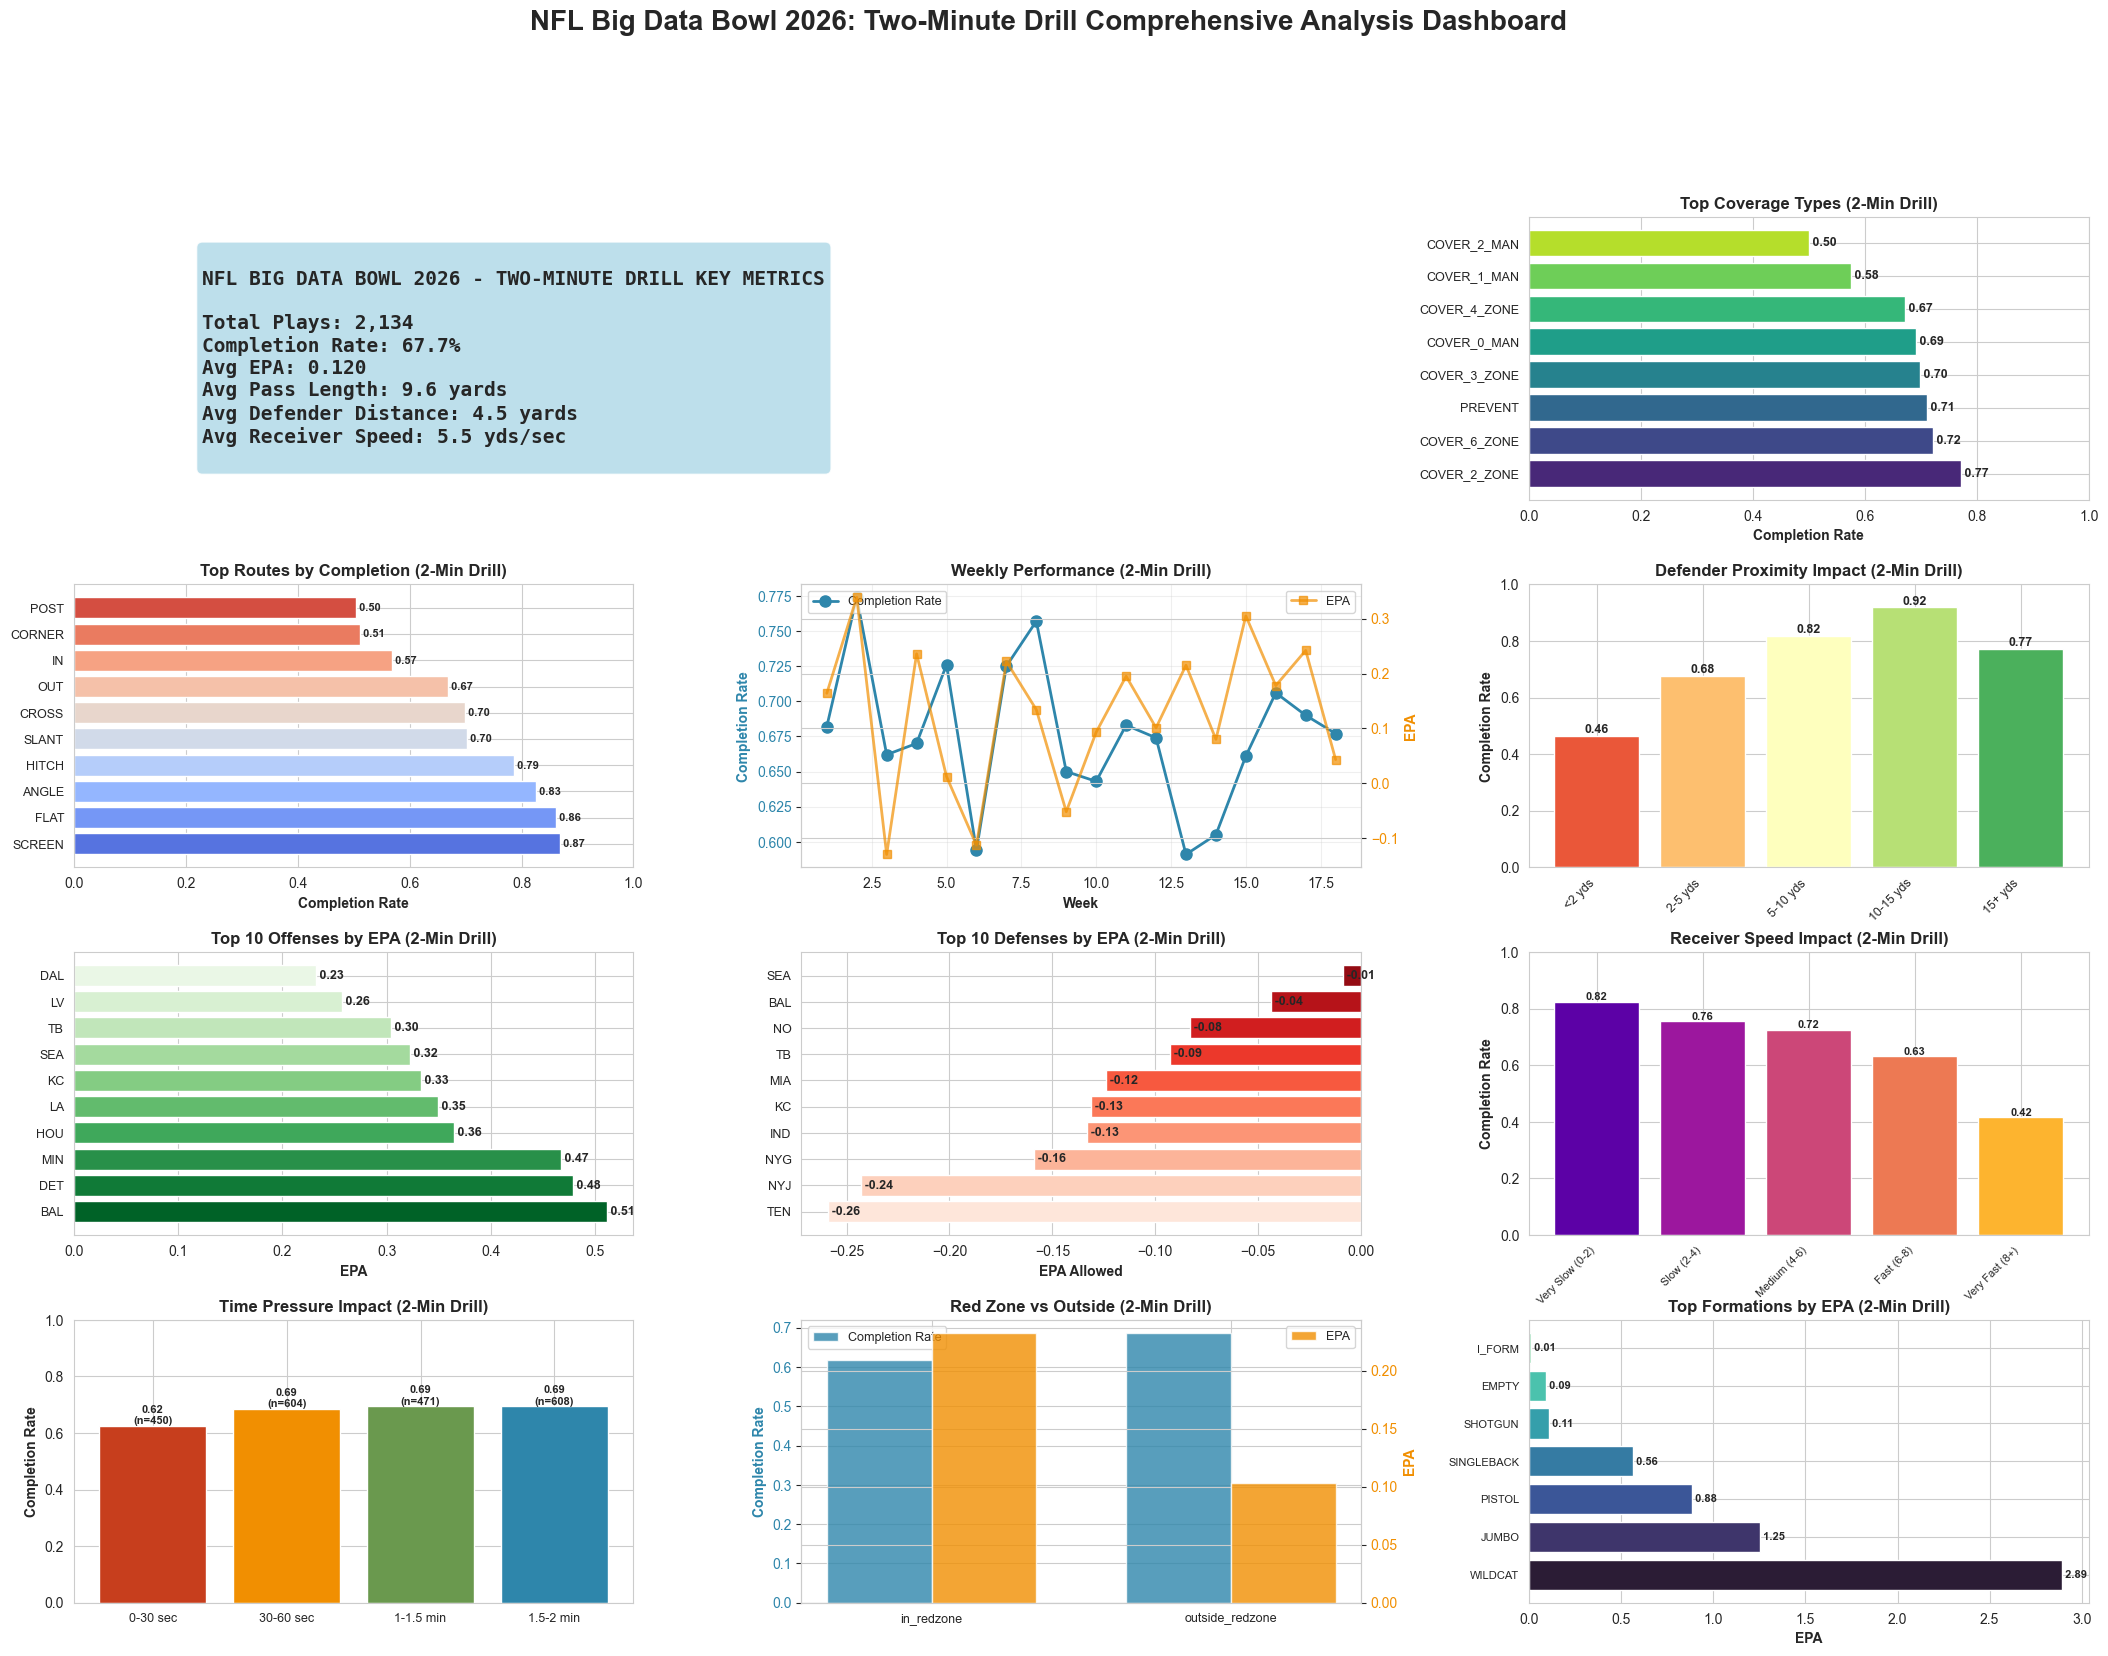


COMPREHENSIVE DASHBOARD CREATED SUCCESSFULLY!


In [94]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(26, 18))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Key Metrics Summary
ax1 = fig.add_subplot(gs[0, :2])
ax1.axis('off')
metrics_text = f"""
NFL BIG DATA BOWL 2026 - TWO-MINUTE DRILL KEY METRICS

Total Plays: {dashboard_data['overall_stats']['total_plays']:,}
Completion Rate: {dashboard_data['overall_stats']['completion_rate']:.1%}
Avg EPA: {dashboard_data['overall_stats']['avg_epa']:.3f}
Avg Pass Length: {dashboard_data['overall_stats']['avg_pass_length']:.1f} yards
Avg Defender Distance: {dashboard_data['overall_stats']['avg_defender_proximity']:.1f} yards
Avg Receiver Speed: {dashboard_data['overall_stats']['avg_receiver_speed']:.1f} yds/sec
"""
ax1.text(0.1, 0.5, metrics_text, fontsize=14, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
         family='monospace', fontweight='bold')

# 2. Completion Rate by Coverage
ax2 = fig.add_subplot(gs[0, 2])
coverage_top = dashboard_data['coverage_stats'].head(8)
bars = ax2.barh(range(len(coverage_top)), coverage_top['is_completion'], 
                color=sns.color_palette("viridis", len(coverage_top)))
ax2.set_yticks(range(len(coverage_top)))
ax2.set_yticklabels(coverage_top.index, fontsize=9)
ax2.set_xlabel('Completion Rate', fontweight='bold')
ax2.set_title('Top Coverage Types (2-Min Drill)', fontweight='bold', fontsize=12)
ax2.set_xlim([0, 1])
for i, (bar, val) in enumerate(zip(bars, coverage_top['is_completion'])):
    ax2.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 3. Route Effectiveness
ax3 = fig.add_subplot(gs[1, 0])
route_top = dashboard_data['route_stats'].head(10)
bars = ax3.barh(range(len(route_top)), route_top['is_completion'],
                color=sns.color_palette("coolwarm", len(route_top)))
ax3.set_yticks(range(len(route_top)))
ax3.set_yticklabels(route_top.index, fontsize=9)
ax3.set_xlabel('Completion Rate', fontweight='bold')
ax3.set_title('Top Routes by Completion (2-Min Drill)', fontweight='bold', fontsize=12)
ax3.set_xlim([0, 1])
for i, (bar, val) in enumerate(zip(bars, route_top['is_completion'])):
    ax3.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=8, fontweight='bold')

# 4. Weekly Trends
ax4 = fig.add_subplot(gs[1, 1])
weekly = dashboard_data['weekly_trends']
ax4.plot(weekly.index, weekly['is_completion'], marker='o', linewidth=2, 
         markersize=8, color='#2E86AB', label='Completion Rate')
ax4_twin = ax4.twinx()
ax4_twin.plot(weekly.index, weekly['expected_points_added'], marker='s', 
              linewidth=2, markersize=6, color='#F18F01', label='EPA', alpha=0.7)
ax4.set_xlabel('Week', fontweight='bold')
ax4.set_ylabel('Completion Rate', fontweight='bold', color='#2E86AB')
ax4_twin.set_ylabel('EPA', fontweight='bold', color='#F18F01')
ax4.set_title('Weekly Performance (2-Min Drill)', fontweight='bold', fontsize=12)
ax4.tick_params(axis='y', labelcolor='#2E86AB')
ax4_twin.tick_params(axis='y', labelcolor='#F18F01')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)

# 5. Defender Proximity Impact
ax5 = fig.add_subplot(gs[1, 2])
defender_prox = dashboard_data['defender_proximity_stats']
bars = ax5.bar(range(len(defender_prox)), defender_prox['is_completion'],
               color=sns.color_palette("RdYlGn", len(defender_prox)))
ax5.set_xticks(range(len(defender_prox)))
ax5.set_xticklabels(defender_prox.index, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('Completion Rate', fontweight='bold')
ax5.set_title('Defender Proximity Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax5.set_ylim([0, 1])
for bar, val in zip(bars, defender_prox['is_completion']):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Team Offense Rankings
ax6 = fig.add_subplot(gs[2, 0])
team_off = dashboard_data['team_offense_rankings'].head(10)
bars = ax6.barh(range(len(team_off)), team_off['expected_points_added'],
                color=sns.color_palette("Greens_r", len(team_off)))
ax6.set_yticks(range(len(team_off)))
ax6.set_yticklabels(team_off.index, fontsize=9)
ax6.set_xlabel('EPA', fontweight='bold')
ax6.set_title('Top 10 Offenses by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, team_off['expected_points_added'])):
    ax6.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 7. Team Defense Rankings
ax7 = fig.add_subplot(gs[2, 1])
team_def = dashboard_data['team_defense_rankings'].head(10)
bars = ax7.barh(range(len(team_def)), team_def['expected_points_added'],
                color=sns.color_palette("Reds", len(team_def)))
ax7.set_yticks(range(len(team_def)))
ax7.set_yticklabels(team_def.index, fontsize=9)
ax7.set_xlabel('EPA Allowed', fontweight='bold')
ax7.set_title('Top 10 Defenses by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, team_def['expected_points_added'])):
    ax7.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
             va='center', fontsize=9, fontweight='bold')

# 8. Speed Analysis
ax8 = fig.add_subplot(gs[2, 2])
speed = dashboard_data['speed_stats']
bars = ax8.bar(range(len(speed)), speed['is_completion'],
               color=sns.color_palette("plasma", len(speed)))
ax8.set_xticks(range(len(speed)))
ax8.set_xticklabels(speed.index, rotation=45, ha='right', fontsize=8)
ax8.set_ylabel('Completion Rate', fontweight='bold')
ax8.set_title('Receiver Speed Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax8.set_ylim([0, 1])
for bar, val in zip(bars, speed['is_completion']):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 9. Time Pressure Analysis
ax9 = fig.add_subplot(gs[3, 0])
time_pressure = dashboard_data['time_pressure_stats']
bars = ax9.bar(range(len(time_pressure)), time_pressure['is_completion'],
               color=['#C73E1D', '#F18F01', '#6A994E', '#2E86AB'])
ax9.set_xticks(range(len(time_pressure)))
ax9.set_xticklabels(time_pressure.index, rotation=0, fontsize=9)
ax9.set_ylabel('Completion Rate', fontweight='bold')
ax9.set_title('Time Pressure Impact (2-Min Drill)', fontweight='bold', fontsize=12)
ax9.set_ylim([0, 1])
for bar, val, count in zip(bars, time_pressure['is_completion'], time_pressure['play_id']):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}\n(n={int(count)})', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 10. Red Zone Performance
ax10 = fig.add_subplot(gs[3, 1])
redzone = dashboard_data['redzone_stats']
x = np.arange(len(redzone))
width = 0.35
bars1 = ax10.bar(x - width/2, redzone['is_completion'], width, 
                 label='Completion Rate', color='#2E86AB', alpha=0.8)
ax10_twin = ax10.twinx()
bars2 = ax10_twin.bar(x + width/2, redzone['expected_points_added'], width,
                      label='EPA', color='#F18F01', alpha=0.8)
ax10.set_xticks(x)
ax10.set_xticklabels(redzone.index, rotation=0, fontsize=9)
ax10.set_ylabel('Completion Rate', fontweight='bold', color='#2E86AB')
ax10_twin.set_ylabel('EPA', fontweight='bold', color='#F18F01')
ax10.set_title('Red Zone vs Outside (2-Min Drill)', fontweight='bold', fontsize=12)
ax10.tick_params(axis='y', labelcolor='#2E86AB')
ax10_twin.tick_params(axis='y', labelcolor='#F18F01')
ax10.legend(loc='upper left', fontsize=9)
ax10_twin.legend(loc='upper right', fontsize=9)

# 11. Formation Effectiveness
ax11 = fig.add_subplot(gs[3, 2])
formation = dashboard_data['formation_stats'].head(8)
bars = ax11.barh(range(len(formation)), formation['expected_points_added'],
                 color=sns.color_palette("mako", len(formation)))
ax11.set_yticks(range(len(formation)))
ax11.set_yticklabels(formation.index, fontsize=8)
ax11.set_xlabel('EPA', fontweight='bold')
ax11.set_title('Top Formations by EPA (2-Min Drill)', fontweight='bold', fontsize=12)
for i, (bar, val) in enumerate(zip(bars, formation['expected_points_added'])):
    ax11.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
              va='center', fontsize=8, fontweight='bold')

plt.suptitle('NFL Big Data Bowl 2026: Two-Minute Drill Comprehensive Analysis Dashboard', 
             fontsize=20, fontweight='bold', y=0.995)

plt.savefig('Two-Minute Drill/comprehensive_dashboard_2min_drill.png', dpi=300, bbox_inches='tight')
print("✓ Saved comprehensive_dashboard_2min_drill.png")
plt.show()

print("\n" + "="*60)
print("COMPREHENSIVE DASHBOARD CREATED SUCCESSFULLY!")
print("="*60)

# Current Thoughts:

- Useful:
  - Weekly Performance is interesting but there is a lot of variation that might be unnecessary for a final dashboard. 
  - Route vs. coverage effectiveness.
  - What is going to be successful for passes in the redzone under 2 minutes based on what we found?
  - The routes and top coverage types based on completion percentages.
  - The success metrics of EPA and then using a QB receiver connection of one or more.
  - It may be helpful to look at passing plays for Expected Yards. This could be more for game planning.